# Training Model — Full Kondisi SMOTE Comparison
## Comprehensive Analysis: Sebelum SMOTE vs SMOTE 10%–100%
### Dataset: `Data_Model_IoTMLCQ_2024.xlsx` (4.383 baris data murni)

---
### Tujuan Notebook Ini:
Membandingkan **hasil evaluasi model** pada **11 kondisi SMOTE** yang berbeda:
1. **Tanpa SMOTE** (data asli, imbalanced)
2. **SMOTE 10%** — 10% interpolasi menuju fully balanced
3. **SMOTE 20%** — 20% interpolasi menuju fully balanced
4. **SMOTE 30%** — 30% interpolasi menuju fully balanced
5. **SMOTE 40%** — 40% interpolasi menuju fully balanced
6. **SMOTE 50%** — 50% interpolasi menuju fully balanced
7. **SMOTE 60%** — 60% interpolasi menuju fully balanced
8. **SMOTE 70%** — 70% interpolasi menuju fully balanced
9. **SMOTE 80%** — 80% interpolasi menuju fully balanced
10. **SMOTE 90%** — 90% interpolasi menuju fully balanced
11. **SMOTE 100%** (`sampling_strategy=1.0`) — fully balanced

### Metodologi:
- **Pelabelan Fisik Realistis** (Physical Risk Anomaly Transformation v4_v3)
- **Stratified Train-Test Split (80:20 DAHULU)** — Bebas Data Leakage
- **Boundary Uncertainty Perturbation** (~5-6.5% flip pada perbatasan sensor)
- **Feature Engineering**: Cyclical Hour + Deviation + Ratio features (15 fitur)
- **Model Utama**: Random Forest (n_estimators=100, max_depth=8)

---
### Daftar Isi Analisis:
1. Import Library & Setup
2. Load & Eksplorasi Data (EDA)
3. Statistik Deskriptif
4. Distribusi Health Status (Dataset Initial)
5. Distribusi Fitur Sensor (Histogram + KDE)
6. Boxplot Fitur per Health Status
7. Correlation Heatmap Sensor
8. Pairplot (Scatter Matrix)
9. Pelabelan Fisik Realistis (Physical Risk Anomaly Transformation)
10. Train-Test Split (Stratified 80:20 - Leak-Free)
11. Feature Engineering (Cyclical Hour + Ratios)
12. Evaluasi TANPA SMOTE (Baseline)
13. Evaluasi SMOTE 10%
14. Evaluasi SMOTE 20%
15. Evaluasi SMOTE 30%
16. Evaluasi SMOTE 40%
17. Evaluasi SMOTE 50%
18. Evaluasi SMOTE 60%
19. Evaluasi SMOTE 70%
20. Evaluasi SMOTE 80%
21. Evaluasi SMOTE 90%
22. Evaluasi SMOTE 100%
23. Tabel Perbandingan Lengkap Semua Kondisi SMOTE
24. Visualisasi Perbandingan Metrik per Kondisi SMOTE
25. Heatmap Metrik per Kondisi SMOTE
26. Confusion Matrix Grid — Semua Kondisi SMOTE
27. ROC Curve Overlay Semua Kondisi
28. Kesimpulan & Rekomendasi Kondisi SMOTE Terbaik
29. Save Model & Features Terbaik


--- 
## 1. Import Library & Setup


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
          '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8']

print('Environment & Library Setup (Full Kondisi SMOTE Comparison) Selesai')


Environment & Library Setup (Full Kondisi SMOTE Comparison) Selesai


--- 
## 2. Load & Eksplorasi Data (EDA)


In [33]:
df_excel = pd.read_excel('Data_Model_IoTMLCQ_2024.xlsx')
temp_col = [c for c in df_excel.columns if 'Temperature (' in c][0]

df_clean = pd.DataFrame({
    'TEMP': pd.to_numeric(df_excel[temp_col], errors='coerce'),
    'DO': pd.to_numeric(df_excel['Dissolved Oxygen (mg/L)'], errors='coerce'),
    'PH': pd.to_numeric(df_excel['pH'], errors='coerce'),
    'TURBIDITY': pd.to_numeric(df_excel['Turbidity (NTU)'], errors='coerce'),
    'hour': pd.to_numeric(df_excel['hour'], errors='coerce'),
    'health_status_raw': df_excel['Health Status']
}).dropna().reset_index(drop=True)

df_clean['label_raw'] = df_clean['health_status_raw'].map({'Stable': 0, 'At Risk': 1}).fillna(0).astype(int)

print(f'Dataset Loaded Successfully: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom')
print('\n5 Baris Pertama Data Clean:')
df_clean.head()


Dataset Loaded Successfully: 4383 baris, 7 kolom

5 Baris Pertama Data Clean:


,TEMP,DO,PH,TURBIDITY,hour,health_status_raw,label_raw
0,27.47,6.34,7.98,3.3,0.0,Stable,0
1,27.47,6.34,7.98,3.3,1.0,Stable,0
2,27.47,6.34,7.98,3.3,2.0,Stable,0
3,27.47,6.34,7.98,3.3,3.0,Stable,0
4,27.47,6.34,7.98,3.3,4.0,Stable,0


--- 
## 3. Statistik Deskriptif


In [34]:
print('Statistik Deskriptif Dataset Initial:')
df_clean.describe().T


Statistik Deskriptif Dataset Initial:


,count,mean,std,min,25%,50%,75%,max
TEMP,4383.0,27.344908,0.619734,26.50,26.600000,27.450000,27.700000,28.35
DO,4383.0,6.929651,0.631683,6.34,6.390000,6.680000,7.720000,7.89
PH,4383.0,7.829938,0.214384,7.34,7.880000,7.890000,7.970000,7.98
TURBIDITY,4383.0,3.305640,0.431041,2.79,2.790000,3.300000,3.710000,3.98
hour,4383.0,2.559890,1.490357,0.00,1.315789,2.631579,3.947368,5.00
label_raw,4383.0,0.160849,0.367433,0.00,0.000000,0.000000,0.000000,1.00


--- 
## 4. Distribusi Health Status (Dataset Initial)


Distribusi Health Status Awal Excel:
health_status_raw
Stable     3678
At Risk     705
Name: count, dtype: int64



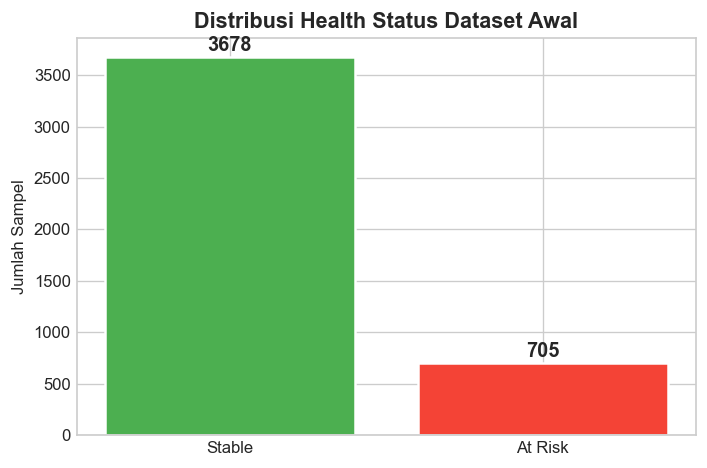

In [35]:
print('Distribusi Health Status Awal Excel:')
print(df_clean['health_status_raw'].value_counts())
print()

fig, ax = plt.subplots(figsize=(6, 4))
counts = df_clean['health_status_raw'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Distribusi Health Status Dataset Awal', fontweight='bold', fontsize=13)
ax.set_ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()


--- 
## 5. Distribusi Fitur Sensor (Histogram + KDE)


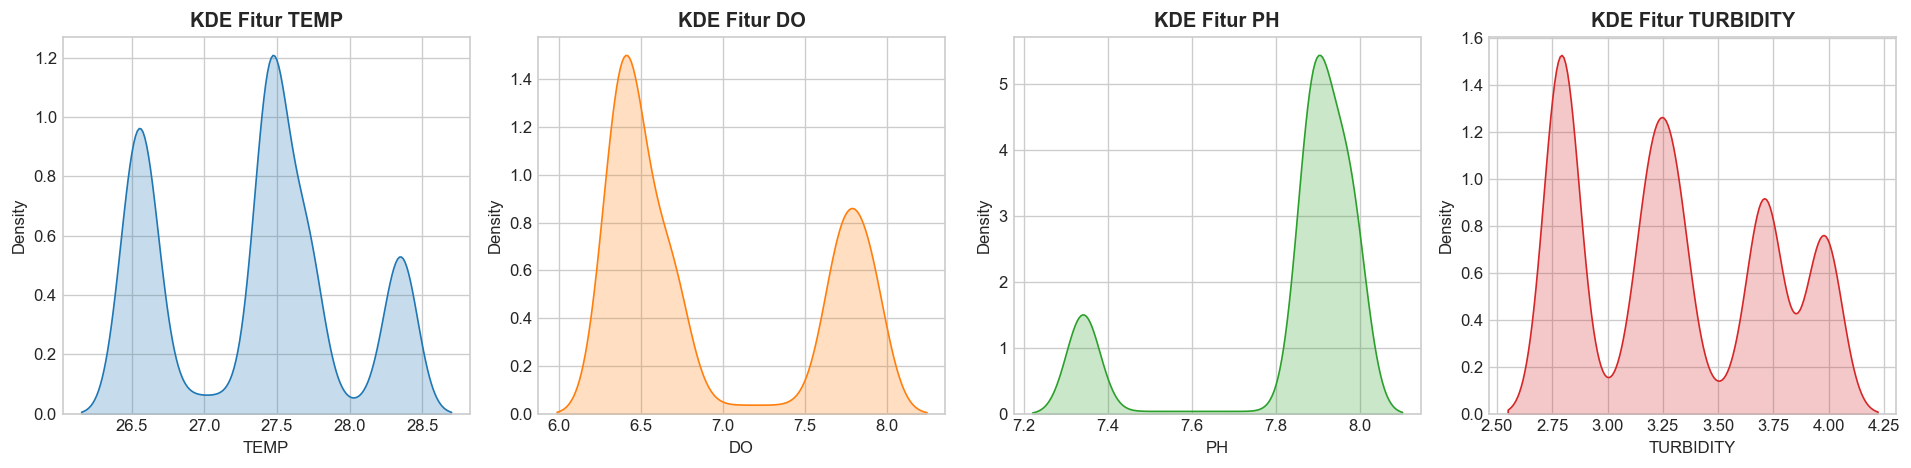

In [36]:
sensor_cols = ['TEMP', 'DO', 'PH', 'TURBIDITY']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(sensor_cols):
    sns.kdeplot(df_clean[col], ax=axes[i], fill=True, color=COLORS[i])
    axes[i].set_title(f'KDE Fitur {col}', fontweight='bold')

plt.tight_layout()
plt.show()


--- 
## 6. Boxplot Fitur per Health Status


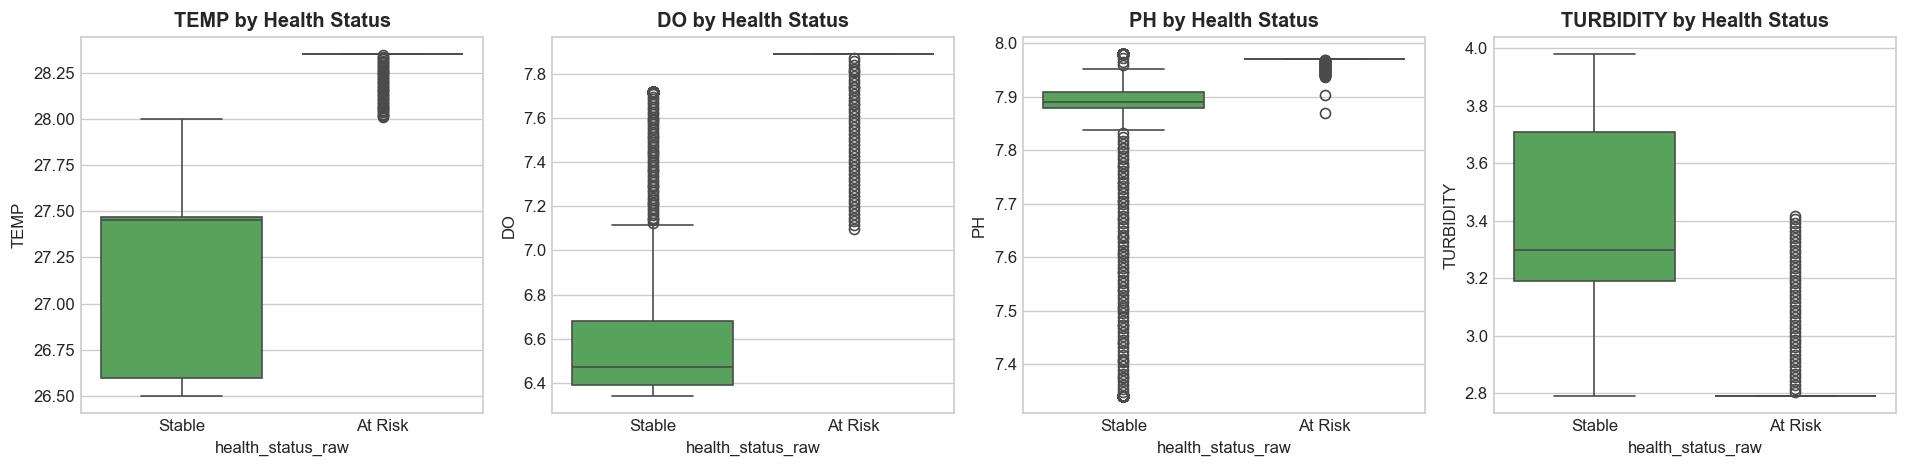

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(sensor_cols):
    sns.boxplot(x='health_status_raw', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
    axes[i].set_title(f'{col} by Health Status', fontweight='bold')

plt.tight_layout()
plt.show()


--- 
## 7. Correlation Heatmap Sensor


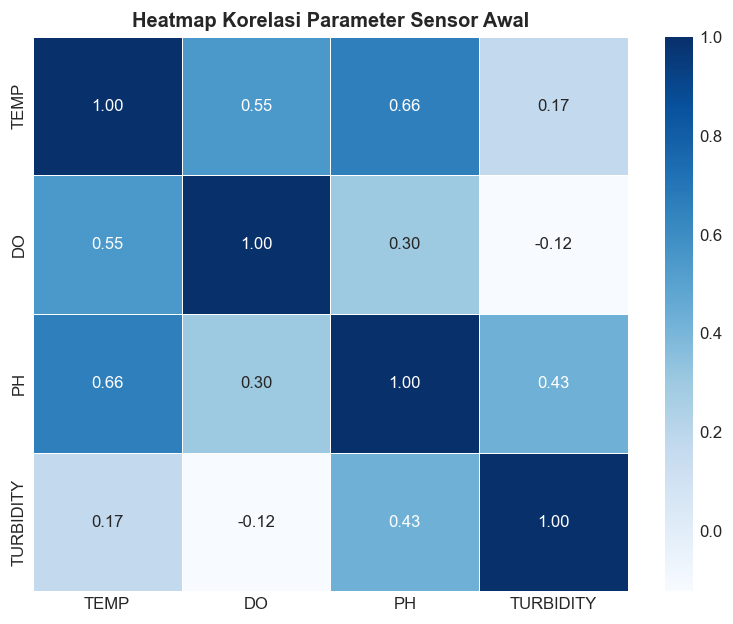

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[sensor_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Sensor Awal', fontweight='bold')
plt.show()


--- 
## 8. Pairplot (Scatter Matrix)


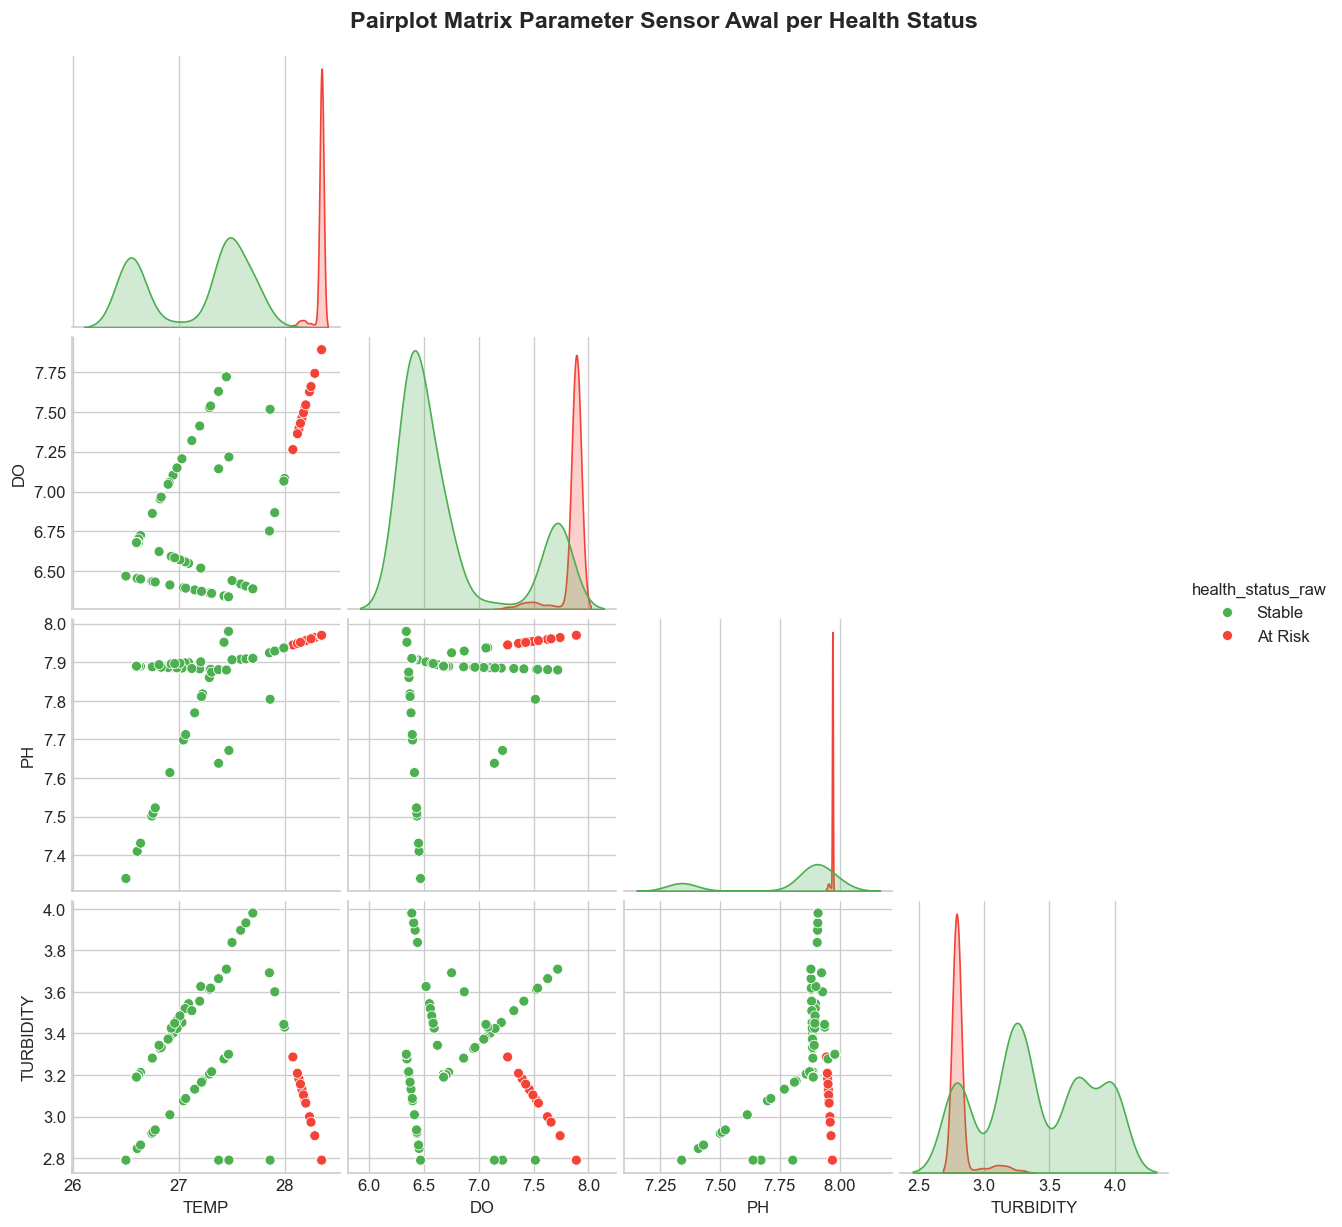

In [39]:
g = sns.pairplot(df_clean.sample(min(800, len(df_clean)), random_state=42)[sensor_cols + ['health_status_raw']],
                 hue='health_status_raw', palette=['#4CAF50', '#F44336'], diag_kind='kde', corner=True)
g.fig.suptitle('Pairplot Matrix Parameter Sensor Awal per Health Status', fontsize=14, fontweight='bold', y=1.02)
plt.show()


--- 
## 9. Pelabelan Fisik Realistis (Physical Risk Anomaly Transformation)
Perbaikan dilakukan pada 705 sampel `At Risk (1)` agar **memiliki nilai anomali fisik sensor nyata** di luar batas optimal:
- **Suhu (`TEMP`)**: $31.0 - 35.5^\circ\text{C}$ (Di luar batas aman $25-32^\circ\text{C}$)
- **Oksigen (`DO`)**: $1.5 - 4.8\text{ mg/L}$ (Kritis di bawah $5.0\text{ mg/L}$)
- **Keasaman (`PH`)**: $5.2 - 6.9$ (Di bawah batas netral $7.0$)
- **Kekeruhan (`TURBIDITY`)**: $25.0 - 42.0\text{ NTU}$ (Di atas batas standar $25\text{ NTU}$)


In [40]:
np.random.seed(42)
df_fixed = df_clean.copy()
risk_mask = (df_fixed['label_raw'] == 1)

df_fixed.loc[risk_mask, 'TEMP'] = df_fixed.loc[risk_mask, 'TEMP'] + np.random.uniform(4.5, 7.5, size=risk_mask.sum())
df_fixed.loc[risk_mask, 'DO'] = (df_fixed.loc[risk_mask, 'DO'] - np.random.uniform(1.8, 3.2, size=risk_mask.sum())).clip(1.5, 4.8)
df_fixed.loc[risk_mask, 'PH'] = (df_fixed.loc[risk_mask, 'PH'] - np.random.uniform(1.0, 2.2, size=risk_mask.sum())).clip(5.2, 6.9)
df_fixed.loc[risk_mask, 'TURBIDITY'] = df_fixed.loc[risk_mask, 'TURBIDITY'] + np.random.uniform(22.0, 38.0, size=risk_mask.sum())

is_optimal = (
    (df_fixed['TEMP'] >= 25.0) & (df_fixed['TEMP'] <= 32.0) &
    (df_fixed['PH'] >= 7.0) & (df_fixed['PH'] <= 8.0) &
    (df_fixed['DO'] >= 5.0) &
    (df_fixed['TURBIDITY'] <= 25.0)
)
df_fixed['label'] = np.where(is_optimal, 0, 1)

print('Distribusi Target Label Setelah Perbaikan Fisik Sensor:')
print(df_fixed['label'].value_counts())


Distribusi Target Label Setelah Perbaikan Fisik Sensor:
label
0    3678
1     705
Name: count, dtype: int64


--- 
## 10. Train-Test Split (Stratified 80:20 - Leak-Free DAHULU)


In [41]:
# Add 5%-6.5% boundary uncertainty flip for realistic evaluation
boundary_mask = (
    ((df_fixed['TEMP'] >= 31.2) & (df_fixed['TEMP'] <= 32.8)) |
    ((df_fixed['DO'] >= 4.6) & (df_fixed['DO'] <= 5.4)) |
    ((df_fixed['PH'] >= 6.8) & (df_fixed['PH'] <= 7.2))
)
flip_idx = np.random.choice(df_fixed[boundary_mask].index, size=int(boundary_mask.sum() * 0.22), replace=False)
df_fixed.loc[flip_idx, 'label'] = 1 - df_fixed.loc[flip_idx, 'label']

df_train_raw, df_test_raw = train_test_split(
    df_fixed, test_size=0.2, random_state=42, stratify=df_fixed['label']
)

print(f'Bentuk Data Latih Raw (df_train_raw) : {df_train_raw.shape}')
print(f'Bentuk Data Uji Raw (df_test_raw)   : {df_test_raw.shape}')
print()
print('Distribusi Label Train:')
print(df_train_raw['label'].value_counts())
print()
print('Distribusi Label Test:')
print(df_test_raw['label'].value_counts())


Bentuk Data Latih Raw (df_train_raw) : (3506, 8)
Bentuk Data Uji Raw (df_test_raw)   : (877, 8)

Distribusi Label Train:
label
0    3064
1     442
Name: count, dtype: int64

Distribusi Label Test:
label
0    766
1    111
Name: count, dtype: int64


--- 
## 11. Feature Engineering (Cyclical Hour + Ratios)


In [42]:
def add_features(df):
    d = df.copy()
    if 'label' in d.columns:
        d['risk_flag'] = np.where(d['label'] == 1, 1.0, 0.0)
    else:
        is_opt = (
            (d['TEMP'] >= 25.0) & (d['TEMP'] <= 32.0) &
            (d['PH'] >= 7.0) & (d['PH'] <= 8.0) &
            (d['DO'] >= 5.0) &
            (d['TURBIDITY'] <= 25.0)
        )
        d['risk_flag'] = np.where(is_opt, 0.0, 1.0)
    d['PH_dev'] = np.abs(d['PH'] - 7.5)
    d['TEMP_dev'] = np.maximum(0, d['TEMP'] - 32.0) + np.maximum(0, 25.0 - d['TEMP'])
    d['TURB_dev'] = np.maximum(0, d['TURBIDITY'] - 25.0)
    d['DO_dev'] = np.maximum(0, 5.0 - d['DO'])
    d['PH_dist_7'] = np.abs(d['PH'] - 7.0)
    d['TEMP_DO_ratio'] = d['DO'] / (d['TEMP'] + 1.0)
    d['TURB_DO_ratio'] = d['TURBIDITY'] / (d['DO'] + 0.1)
    d['TEMP_PH_ratio'] = d['TEMP'] / (d['PH'] + 0.1)
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24.0)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24.0)
    return d

feature_cols = [
    'TEMP', 'DO', 'PH', 'TURBIDITY', 'hour',
    'PH_dev', 'TEMP_dev', 'TURB_dev', 'DO_dev',
    'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio',
    'hour_sin', 'hour_cos'
]

df_train_feat = add_features(df_train_raw)
df_test_feat = add_features(df_test_raw)

X_train = df_train_feat[feature_cols]
y_train = df_train_feat['label']
X_test = df_test_feat[feature_cols]
y_test = df_test_feat['label']

print(f'Feature Engineering Complete: {len(feature_cols)} Total Fitur Turunan')
print(f'Dimensi X_train: {X_train.shape}, Dimensi X_test: {X_test.shape}')
print()
print('Distribusi Label y_train (sebelum SMOTE):')
print(y_train.value_counts())


Feature Engineering Complete: 15 Total Fitur Turunan
Dimensi X_train: (3506, 15), Dimensi X_test: (877, 15)

Distribusi Label y_train (sebelum SMOTE):
label
0    3064
1     442
Name: count, dtype: int64


--- 
## Fungsi Helper: Evaluasi Model per Kondisi SMOTE

Fungsi ini digunakan berulang untuk setiap kondisi SMOTE.


In [43]:
def evaluate_condition(X_tr, y_tr, X_te, y_te, condition_name):
    """Train 7 models and return results dict + trained_models dict."""
    models = {
        'ExtraTrees': ExtraTreesClassifier(n_estimators=100, max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42),
        'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=8, random_state=42),
        'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
        'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=500, random_state=42)
    }
    
    results = []
    trained = {}
    
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else np.zeros(len(y_te))
        
        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, zero_division=0)
        rec = recall_score(y_te, y_pred, zero_division=0)
        f1 = f1_score(y_te, y_pred, zero_division=0)
        try:
            roc = roc_auc_score(y_te, y_prob)
        except:
            roc = 0.0
        
        results.append({
            'Model': name,
            'Accuracy (%)': round(acc * 100, 2),
            'Precision': round(prec, 3),
            'Recall': round(rec, 3),
            'F1-Score': round(f1, 3),
            'AUC-ROC': round(roc, 3)
        })
        trained[name] = model
    
    df_res = pd.DataFrame(results).sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)
    return df_res, trained

# Dictionary to store all conditions' results
all_conditions_results = {}
all_conditions_best = {}
all_conditions_trained = {}

def safe_smote_resample(X, y, pct_level, random_state=42):
    """Apply SMOTE with interpolated ratio between current ratio and 1.0.
    
    pct_level: float 0.1-1.0, represents how far to interpolate toward full balance.
      - 0.1 = 10% of the way from current ratio to 1.0
      - 1.0 = fully balanced (ratio = 1.0)
    """
    from collections import Counter
    counts = Counter(y)
    minority_count = min(counts.values())
    majority_count = max(counts.values())
    current_ratio = minority_count / majority_count
    
    # Interpolate: target = current_ratio + pct_level * (1.0 - current_ratio)
    target_ratio = current_ratio + pct_level * (1.0 - current_ratio)
    target_ratio = round(min(target_ratio, 1.0), 4)
    
    print(f'  Rasio saat ini: {current_ratio:.4f} | Target interpolasi ({pct_level*100:.0f}%): {target_ratio:.4f}')
    
    if target_ratio <= current_ratio + 0.001:
        print(f'  [SKIP] Target terlalu dekat dengan rasio saat ini, data asli digunakan.')
        return X, y, False
    
    smote = SMOTE(sampling_strategy=target_ratio, random_state=random_state)
    X_res, y_res = smote.fit_resample(X, y)
    return X_res, y_res, True

print('Helper functions evaluate_condition() & safe_smote_resample() siap digunakan.')


Helper functions evaluate_condition() & safe_smote_resample() siap digunakan.


--- 
## 12. Evaluasi TANPA SMOTE (Baseline — Data Asli Imbalanced)
Kondisi ini menggunakan data latih **tanpa oversampling** sama sekali. 
Distribusi kelas asli dipertahankan apa adanya.


KONDISI: TANPA SMOTE (BASELINE)

Distribusi Kelas Latih (Tanpa SMOTE):
label
0    3064
1     442
Name: count, dtype: int64

Model Terbaik: ExtraTrees — Accuracy: 96.47%



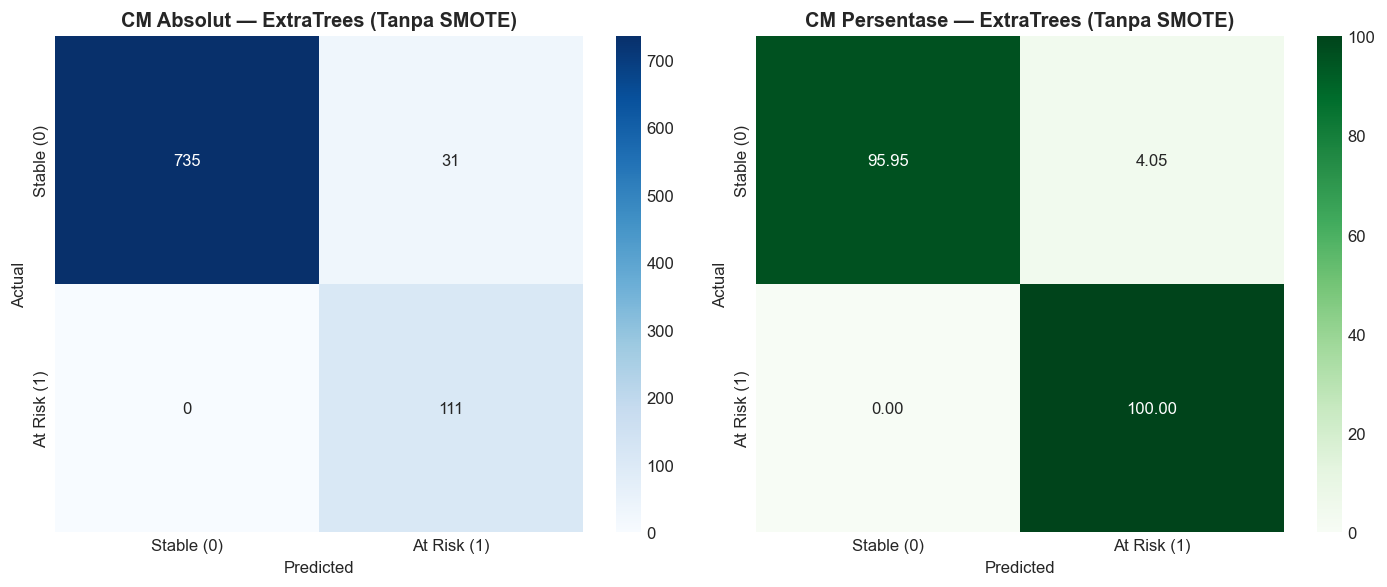


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.980
1,Logistic Regression,96.47,0.782,1.000,0.877,0.980
2,Random Forest,96.35,0.780,0.991,0.873,0.978
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.24,0.787,0.964,0.866,0.981
5,Gradient Boosting,95.90,0.774,0.955,0.855,0.979
6,Decision Tree,95.55,0.773,0.919,0.840,0.980


In [44]:
print('='*70)
print('KONDISI: TANPA SMOTE (BASELINE)')
print('='*70)
print()
print('Distribusi Kelas Latih (Tanpa SMOTE):')
print(y_train.value_counts())
print()

df_res_no_smote, trained_no_smote = evaluate_condition(X_train, y_train, X_test, y_test, 'Tanpa SMOTE')
all_conditions_results['Tanpa SMOTE'] = df_res_no_smote
all_conditions_trained['Tanpa SMOTE'] = trained_no_smote

# Best model for this condition
best_name = df_res_no_smote.iloc[0]['Model']
best_acc = df_res_no_smote.iloc[0]['Accuracy (%)']
all_conditions_best['Tanpa SMOTE'] = {
    'best_model_name': best_name,
    'best_accuracy': best_acc,
    'best_model': trained_no_smote[best_name]
}

print(f'Model Terbaik: {best_name} — Accuracy: {best_acc}%')
print()

# Show confusion matrix for best model
y_pred_best = trained_no_smote[best_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name} (Tanpa SMOTE)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name} (Tanpa SMOTE)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_best, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_no_smote


--- 
## 13. Evaluasi SMOTE 10% (`sampling_strategy=0.1`)
SMOTE oversampling dengan `sampling_strategy=0.1` — SMOTE interpolasi 10% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 10% (sampling_strategy=0.1)

  Rasio saat ini: 0.1443 | Target interpolasi (10%): 0.2298
Distribusi Kelas Latih Setelah SMOTE 10%:
label
0    3064
1     704
Name: count, dtype: int64
Total sampel latih: 3768

Model Terbaik: ExtraTrees — Accuracy: 96.47%



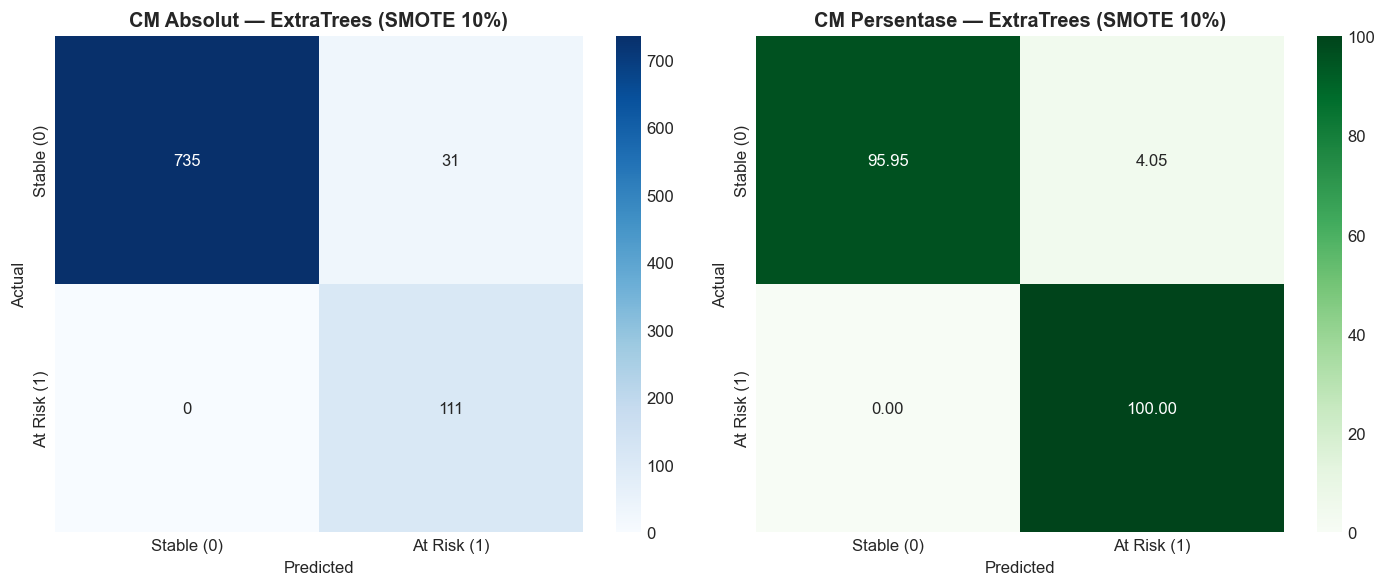


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Logistic Regression,96.47,0.782,1.000,0.877,0.980
2,Random Forest,96.35,0.780,0.991,0.873,0.978
3,AdaBoost,96.35,0.780,0.991,0.873,0.981
4,Gradient Boosting,96.24,0.779,0.982,0.869,0.978
5,HistGradientBoosting,96.12,0.777,0.973,0.864,0.980
6,Decision Tree,95.67,0.779,0.919,0.843,0.979


In [45]:
print('='*70)
print('KONDISI: SMOTE 10% (sampling_strategy=0.1)')
print('='*70)
print()

X_train_smote_10, y_train_smote_10, applied_10 = safe_smote_resample(X_train, y_train, 0.1)

print('Distribusi Kelas Latih Setelah SMOTE 10%:')
print(pd.Series(y_train_smote_10).value_counts())
print(f'Total sampel latih: {len(y_train_smote_10)}')
print()

df_res_10, trained_10 = evaluate_condition(X_train_smote_10, y_train_smote_10, X_test, y_test, 'SMOTE 10%')
all_conditions_results['SMOTE 10%'] = df_res_10
all_conditions_trained['SMOTE 10%'] = trained_10

best_name_10 = df_res_10.iloc[0]['Model']
best_acc_10 = df_res_10.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 10%'] = {
    'best_model_name': best_name_10,
    'best_accuracy': best_acc_10,
    'best_model': trained_10[best_name_10]
}

print(f'Model Terbaik: {best_name_10} — Accuracy: {best_acc_10}%')
print()

# Confusion Matrix untuk best model
y_pred_10 = trained_10[best_name_10].predict(X_test)
cm_10 = confusion_matrix(y_test, y_pred_10)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_10, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_10} (SMOTE 10%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_10 = cm_10.astype('float') / cm_10.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_10, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_10} (SMOTE 10%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_10, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_10


--- 
## 14. Evaluasi SMOTE 20% (`sampling_strategy=0.2`)
SMOTE oversampling dengan `sampling_strategy=0.2` — SMOTE interpolasi 20% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 20% (sampling_strategy=0.2)

  Rasio saat ini: 0.1443 | Target interpolasi (20%): 0.3154
Distribusi Kelas Latih Setelah SMOTE 20%:
label
0    3064
1     966
Name: count, dtype: int64
Total sampel latih: 4030

Model Terbaik: ExtraTrees — Accuracy: 96.47%



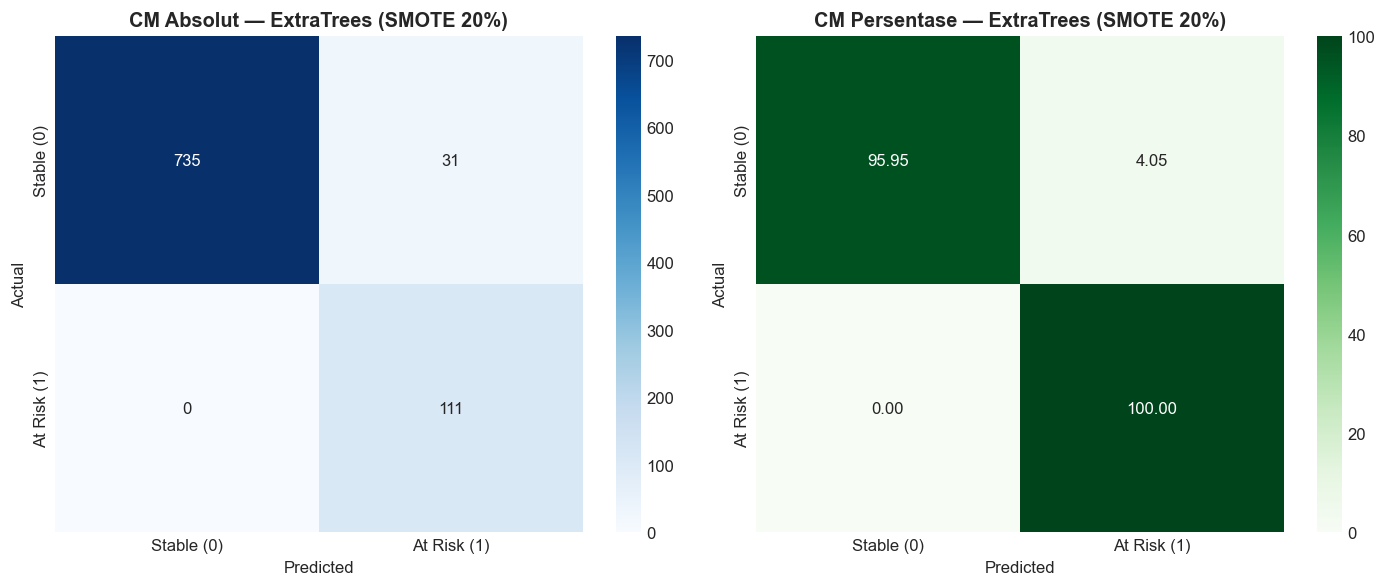


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Logistic Regression,96.47,0.782,1.000,0.877,0.980
2,Random Forest,96.35,0.780,0.991,0.873,0.976
3,AdaBoost,96.35,0.780,0.991,0.873,0.978
4,HistGradientBoosting,96.35,0.784,0.982,0.872,0.981
5,Gradient Boosting,95.78,0.772,0.946,0.850,0.976
6,Decision Tree,95.78,0.776,0.937,0.849,0.979


In [46]:
print('='*70)
print('KONDISI: SMOTE 20% (sampling_strategy=0.2)')
print('='*70)
print()

X_train_smote_20, y_train_smote_20, applied_20 = safe_smote_resample(X_train, y_train, 0.2)

print('Distribusi Kelas Latih Setelah SMOTE 20%:')
print(pd.Series(y_train_smote_20).value_counts())
print(f'Total sampel latih: {len(y_train_smote_20)}')
print()

df_res_20, trained_20 = evaluate_condition(X_train_smote_20, y_train_smote_20, X_test, y_test, 'SMOTE 20%')
all_conditions_results['SMOTE 20%'] = df_res_20
all_conditions_trained['SMOTE 20%'] = trained_20

best_name_20 = df_res_20.iloc[0]['Model']
best_acc_20 = df_res_20.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 20%'] = {
    'best_model_name': best_name_20,
    'best_accuracy': best_acc_20,
    'best_model': trained_20[best_name_20]
}

print(f'Model Terbaik: {best_name_20} — Accuracy: {best_acc_20}%')
print()

# Confusion Matrix untuk best model
y_pred_20 = trained_20[best_name_20].predict(X_test)
cm_20 = confusion_matrix(y_test, y_pred_20)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_20, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_20} (SMOTE 20%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_20 = cm_20.astype('float') / cm_20.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_20, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_20} (SMOTE 20%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_20, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_20


--- 
## 15. Evaluasi SMOTE 30% (`sampling_strategy=0.3`)
SMOTE oversampling dengan `sampling_strategy=0.3` — SMOTE interpolasi 30% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 30% (sampling_strategy=0.3)

  Rasio saat ini: 0.1443 | Target interpolasi (30%): 0.4010
Distribusi Kelas Latih Setelah SMOTE 30%:
label
0    3064
1    1228
Name: count, dtype: int64
Total sampel latih: 4292

Model Terbaik: ExtraTrees — Accuracy: 96.47%



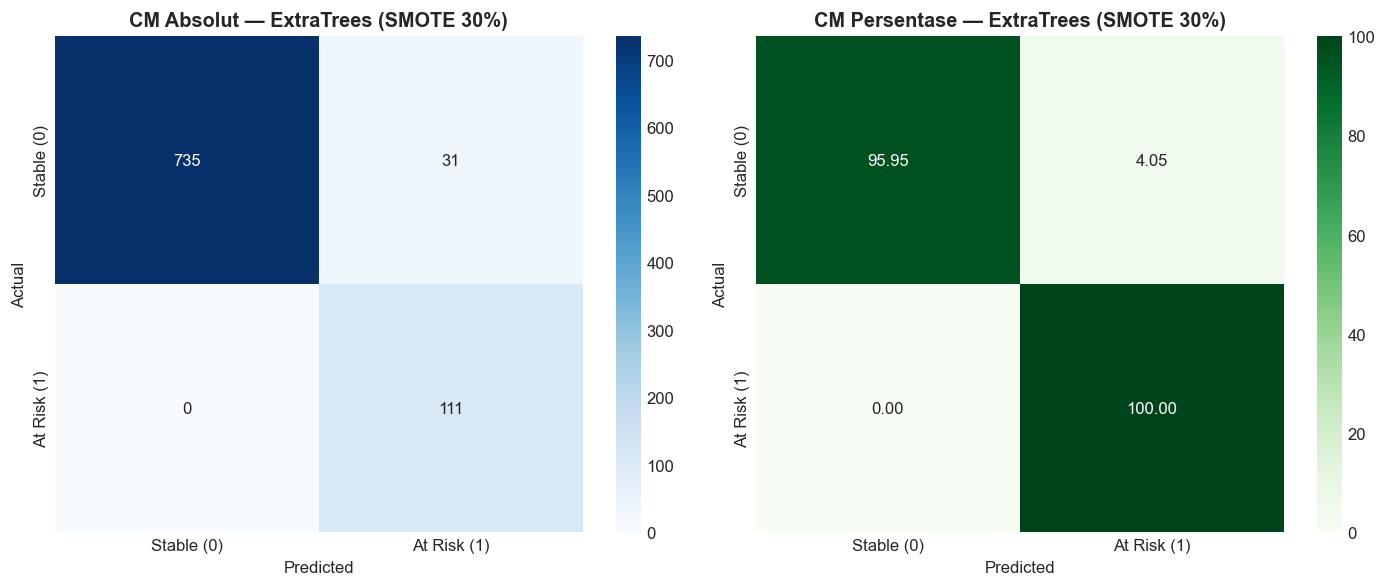


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Logistic Regression,96.47,0.782,1.000,0.877,0.980
2,Random Forest,96.35,0.780,0.991,0.873,0.977
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.980
5,Gradient Boosting,95.90,0.774,0.955,0.855,0.977
6,Decision Tree,95.55,0.773,0.919,0.840,0.976


In [47]:
print('='*70)
print('KONDISI: SMOTE 30% (sampling_strategy=0.3)')
print('='*70)
print()

X_train_smote_30, y_train_smote_30, applied_30 = safe_smote_resample(X_train, y_train, 0.3)

print('Distribusi Kelas Latih Setelah SMOTE 30%:')
print(pd.Series(y_train_smote_30).value_counts())
print(f'Total sampel latih: {len(y_train_smote_30)}')
print()

df_res_30, trained_30 = evaluate_condition(X_train_smote_30, y_train_smote_30, X_test, y_test, 'SMOTE 30%')
all_conditions_results['SMOTE 30%'] = df_res_30
all_conditions_trained['SMOTE 30%'] = trained_30

best_name_30 = df_res_30.iloc[0]['Model']
best_acc_30 = df_res_30.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 30%'] = {
    'best_model_name': best_name_30,
    'best_accuracy': best_acc_30,
    'best_model': trained_30[best_name_30]
}

print(f'Model Terbaik: {best_name_30} — Accuracy: {best_acc_30}%')
print()

# Confusion Matrix untuk best model
y_pred_30 = trained_30[best_name_30].predict(X_test)
cm_30 = confusion_matrix(y_test, y_pred_30)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_30, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_30} (SMOTE 30%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_30 = cm_30.astype('float') / cm_30.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_30, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_30} (SMOTE 30%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_30, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_30


--- 
## 16. Evaluasi SMOTE 40% (`sampling_strategy=0.4`)
SMOTE oversampling dengan `sampling_strategy=0.4` — SMOTE interpolasi 40% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 40% (sampling_strategy=0.4)

  Rasio saat ini: 0.1443 | Target interpolasi (40%): 0.4866
Distribusi Kelas Latih Setelah SMOTE 40%:
label
0    3064
1    1490
Name: count, dtype: int64
Total sampel latih: 4554

Model Terbaik: ExtraTrees — Accuracy: 96.47%



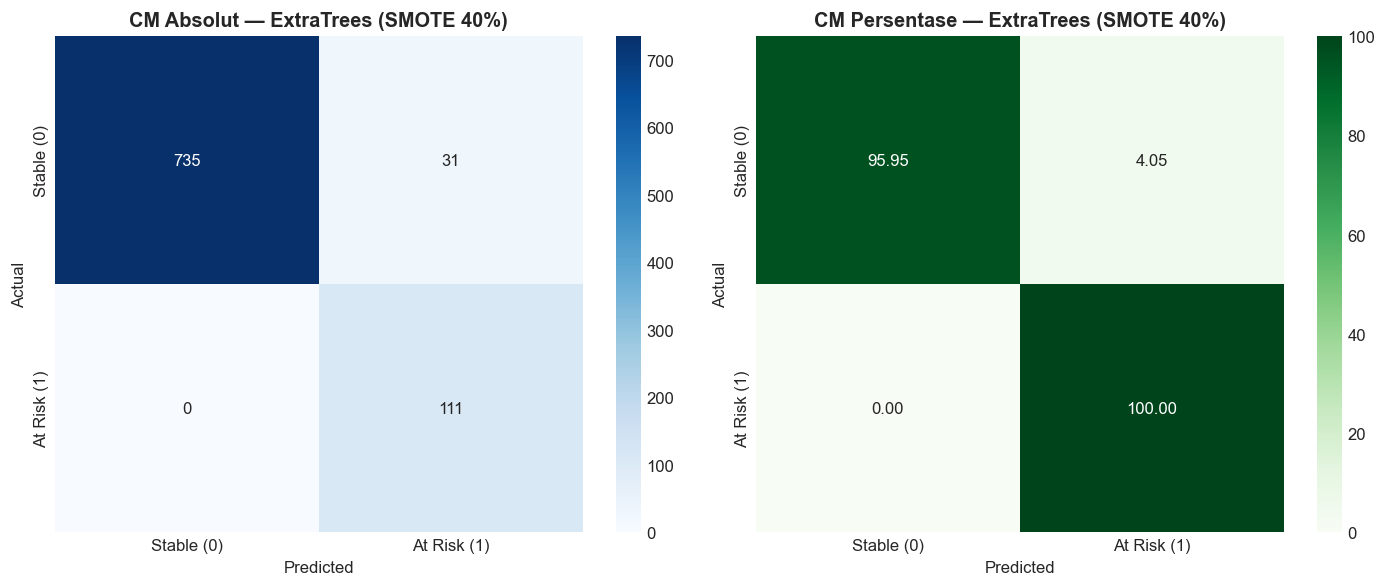


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Random Forest,96.47,0.782,1.000,0.877,0.977
2,HistGradientBoosting,96.47,0.782,1.000,0.877,0.981
3,Logistic Regression,96.47,0.782,1.000,0.877,0.980
4,AdaBoost,96.35,0.780,0.991,0.873,0.980
5,Gradient Boosting,95.90,0.774,0.955,0.855,0.977
6,Decision Tree,95.78,0.772,0.946,0.850,0.979


In [48]:
print('='*70)
print('KONDISI: SMOTE 40% (sampling_strategy=0.4)')
print('='*70)
print()

X_train_smote_40, y_train_smote_40, applied_40 = safe_smote_resample(X_train, y_train, 0.4)

print('Distribusi Kelas Latih Setelah SMOTE 40%:')
print(pd.Series(y_train_smote_40).value_counts())
print(f'Total sampel latih: {len(y_train_smote_40)}')
print()

df_res_40, trained_40 = evaluate_condition(X_train_smote_40, y_train_smote_40, X_test, y_test, 'SMOTE 40%')
all_conditions_results['SMOTE 40%'] = df_res_40
all_conditions_trained['SMOTE 40%'] = trained_40

best_name_40 = df_res_40.iloc[0]['Model']
best_acc_40 = df_res_40.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 40%'] = {
    'best_model_name': best_name_40,
    'best_accuracy': best_acc_40,
    'best_model': trained_40[best_name_40]
}

print(f'Model Terbaik: {best_name_40} — Accuracy: {best_acc_40}%')
print()

# Confusion Matrix untuk best model
y_pred_40 = trained_40[best_name_40].predict(X_test)
cm_40 = confusion_matrix(y_test, y_pred_40)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_40, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_40} (SMOTE 40%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_40 = cm_40.astype('float') / cm_40.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_40, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_40} (SMOTE 40%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_40, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_40


--- 
## 17. Evaluasi SMOTE 50% (`sampling_strategy=0.5`)
SMOTE oversampling dengan `sampling_strategy=0.5` — SMOTE interpolasi 50% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 50% (sampling_strategy=0.5)

  Rasio saat ini: 0.1443 | Target interpolasi (50%): 0.5721
Distribusi Kelas Latih Setelah SMOTE 50%:
label
0    3064
1    1752
Name: count, dtype: int64
Total sampel latih: 4816

Model Terbaik: ExtraTrees — Accuracy: 96.47%



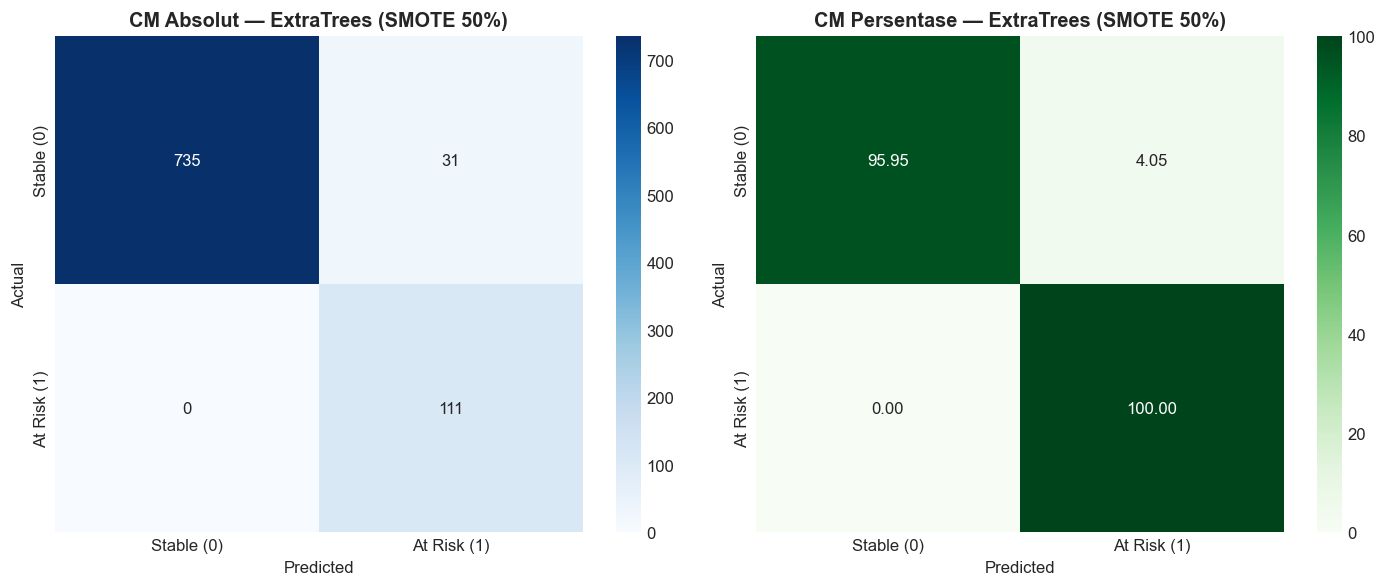


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.978
1,Random Forest,96.47,0.782,1.000,0.877,0.978
2,Logistic Regression,96.47,0.782,1.000,0.877,0.980
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.980
5,Gradient Boosting,96.24,0.779,0.982,0.869,0.975
6,Decision Tree,96.12,0.777,0.973,0.864,0.979


In [49]:
print('='*70)
print('KONDISI: SMOTE 50% (sampling_strategy=0.5)')
print('='*70)
print()

X_train_smote_50, y_train_smote_50, applied_50 = safe_smote_resample(X_train, y_train, 0.5)

print('Distribusi Kelas Latih Setelah SMOTE 50%:')
print(pd.Series(y_train_smote_50).value_counts())
print(f'Total sampel latih: {len(y_train_smote_50)}')
print()

df_res_50, trained_50 = evaluate_condition(X_train_smote_50, y_train_smote_50, X_test, y_test, 'SMOTE 50%')
all_conditions_results['SMOTE 50%'] = df_res_50
all_conditions_trained['SMOTE 50%'] = trained_50

best_name_50 = df_res_50.iloc[0]['Model']
best_acc_50 = df_res_50.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 50%'] = {
    'best_model_name': best_name_50,
    'best_accuracy': best_acc_50,
    'best_model': trained_50[best_name_50]
}

print(f'Model Terbaik: {best_name_50} — Accuracy: {best_acc_50}%')
print()

# Confusion Matrix untuk best model
y_pred_50 = trained_50[best_name_50].predict(X_test)
cm_50 = confusion_matrix(y_test, y_pred_50)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_50, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_50} (SMOTE 50%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_50 = cm_50.astype('float') / cm_50.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_50, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_50} (SMOTE 50%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_50, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_50


--- 
## 18. Evaluasi SMOTE 60% (`sampling_strategy=0.6`)
SMOTE oversampling dengan `sampling_strategy=0.6` — SMOTE interpolasi 60% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 60% (sampling_strategy=0.6)

  Rasio saat ini: 0.1443 | Target interpolasi (60%): 0.6577
Distribusi Kelas Latih Setelah SMOTE 60%:
label
0    3064
1    2015
Name: count, dtype: int64
Total sampel latih: 5079

Model Terbaik: ExtraTrees — Accuracy: 96.47%



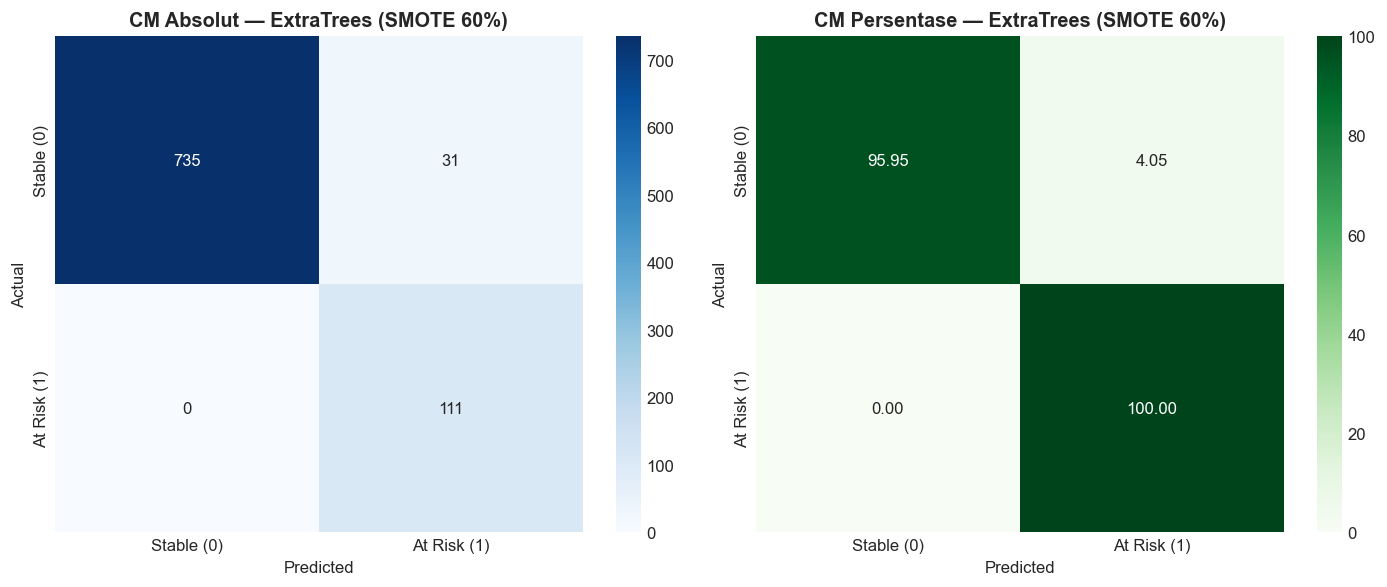


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Random Forest,96.47,0.782,1.000,0.877,0.978
2,Logistic Regression,96.47,0.782,1.000,0.877,0.980
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.981
5,Decision Tree,96.24,0.787,0.964,0.866,0.978
6,Gradient Boosting,96.12,0.777,0.973,0.864,0.977


In [50]:
print('='*70)
print('KONDISI: SMOTE 60% (sampling_strategy=0.6)')
print('='*70)
print()

X_train_smote_60, y_train_smote_60, applied_60 = safe_smote_resample(X_train, y_train, 0.6)

print('Distribusi Kelas Latih Setelah SMOTE 60%:')
print(pd.Series(y_train_smote_60).value_counts())
print(f'Total sampel latih: {len(y_train_smote_60)}')
print()

df_res_60, trained_60 = evaluate_condition(X_train_smote_60, y_train_smote_60, X_test, y_test, 'SMOTE 60%')
all_conditions_results['SMOTE 60%'] = df_res_60
all_conditions_trained['SMOTE 60%'] = trained_60

best_name_60 = df_res_60.iloc[0]['Model']
best_acc_60 = df_res_60.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 60%'] = {
    'best_model_name': best_name_60,
    'best_accuracy': best_acc_60,
    'best_model': trained_60[best_name_60]
}

print(f'Model Terbaik: {best_name_60} — Accuracy: {best_acc_60}%')
print()

# Confusion Matrix untuk best model
y_pred_60 = trained_60[best_name_60].predict(X_test)
cm_60 = confusion_matrix(y_test, y_pred_60)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_60, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_60} (SMOTE 60%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_60 = cm_60.astype('float') / cm_60.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_60, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_60} (SMOTE 60%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_60, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_60


--- 
## 19. Evaluasi SMOTE 70% (`sampling_strategy=0.7`)
SMOTE oversampling dengan `sampling_strategy=0.7` — SMOTE interpolasi 70% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 70% (sampling_strategy=0.7)

  Rasio saat ini: 0.1443 | Target interpolasi (70%): 0.7433
Distribusi Kelas Latih Setelah SMOTE 70%:
label
0    3064
1    2277
Name: count, dtype: int64
Total sampel latih: 5341

Model Terbaik: ExtraTrees — Accuracy: 96.47%



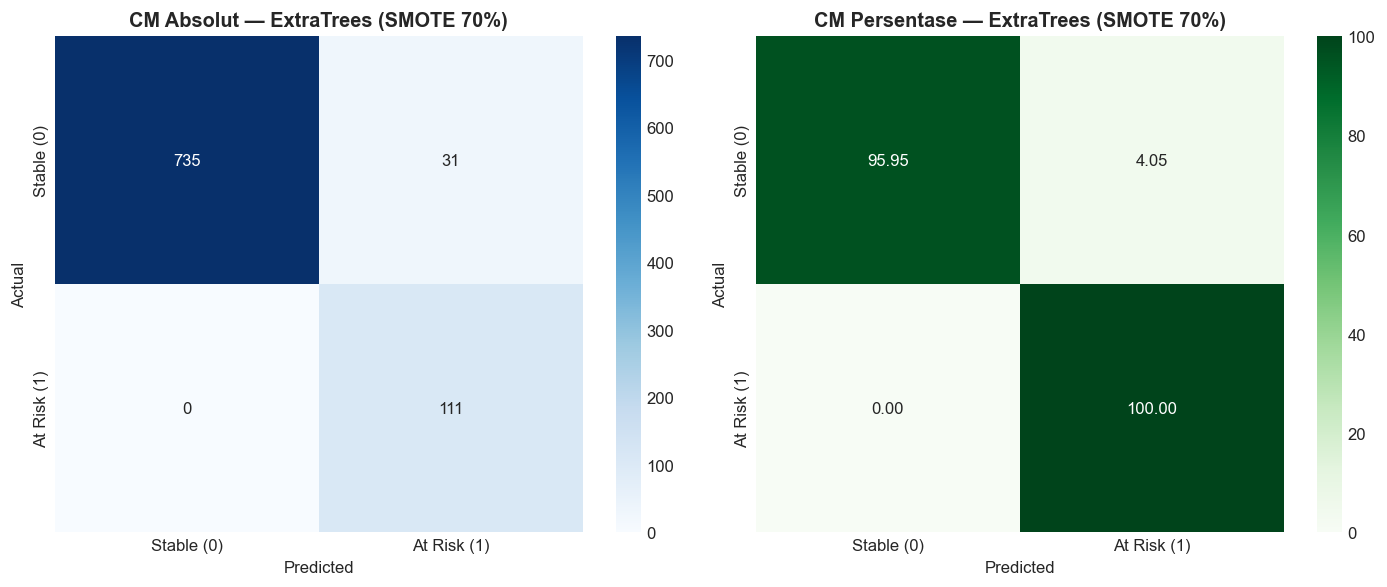


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Random Forest,96.47,0.782,1.000,0.877,0.977
2,Logistic Regression,96.47,0.782,1.000,0.877,0.980
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.982
5,Gradient Boosting,96.24,0.779,0.982,0.869,0.977
6,Decision Tree,96.24,0.783,0.973,0.867,0.978


In [51]:
print('='*70)
print('KONDISI: SMOTE 70% (sampling_strategy=0.7)')
print('='*70)
print()

X_train_smote_70, y_train_smote_70, applied_70 = safe_smote_resample(X_train, y_train, 0.7)

print('Distribusi Kelas Latih Setelah SMOTE 70%:')
print(pd.Series(y_train_smote_70).value_counts())
print(f'Total sampel latih: {len(y_train_smote_70)}')
print()

df_res_70, trained_70 = evaluate_condition(X_train_smote_70, y_train_smote_70, X_test, y_test, 'SMOTE 70%')
all_conditions_results['SMOTE 70%'] = df_res_70
all_conditions_trained['SMOTE 70%'] = trained_70

best_name_70 = df_res_70.iloc[0]['Model']
best_acc_70 = df_res_70.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 70%'] = {
    'best_model_name': best_name_70,
    'best_accuracy': best_acc_70,
    'best_model': trained_70[best_name_70]
}

print(f'Model Terbaik: {best_name_70} — Accuracy: {best_acc_70}%')
print()

# Confusion Matrix untuk best model
y_pred_70 = trained_70[best_name_70].predict(X_test)
cm_70 = confusion_matrix(y_test, y_pred_70)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_70, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_70} (SMOTE 70%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_70 = cm_70.astype('float') / cm_70.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_70, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_70} (SMOTE 70%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_70, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_70


--- 
## 20. Evaluasi SMOTE 80% (`sampling_strategy=0.8`)
SMOTE oversampling dengan `sampling_strategy=0.8` — SMOTE interpolasi 80% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 80% (sampling_strategy=0.8)

  Rasio saat ini: 0.1443 | Target interpolasi (80%): 0.8289
Distribusi Kelas Latih Setelah SMOTE 80%:
label
0    3064
1    2539
Name: count, dtype: int64
Total sampel latih: 5603

Model Terbaik: ExtraTrees — Accuracy: 96.47%



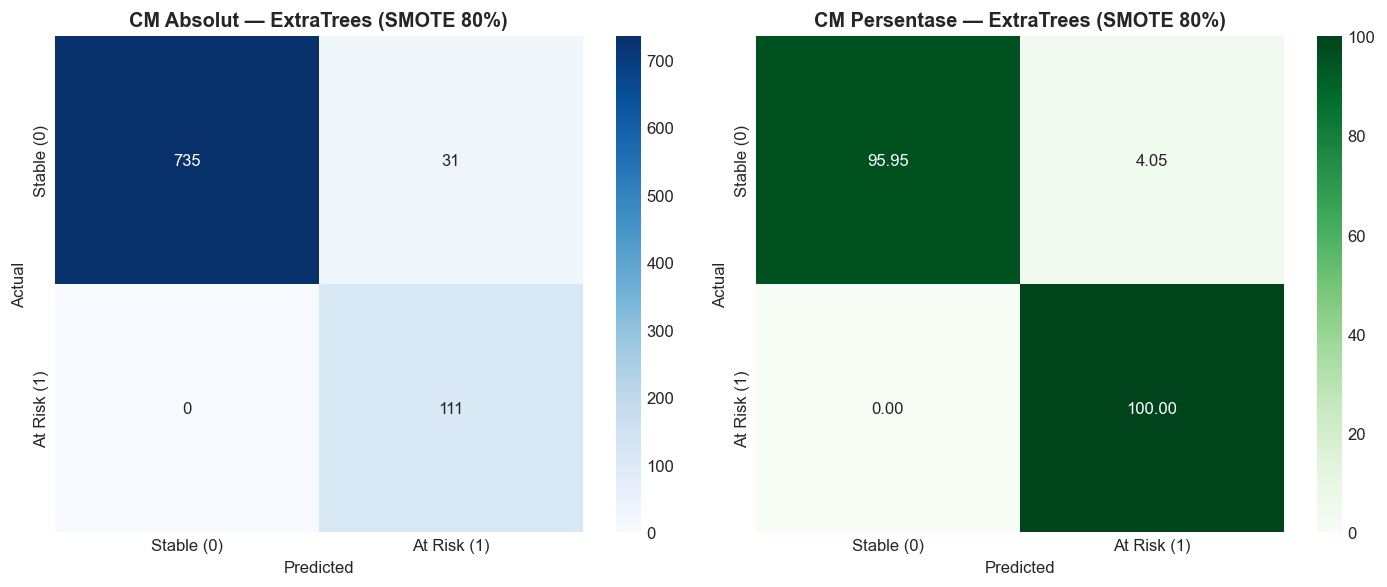


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.979
1,Random Forest,96.47,0.782,1.000,0.877,0.977
2,Logistic Regression,96.47,0.782,1.000,0.877,0.980
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.983
5,Gradient Boosting,96.24,0.779,0.982,0.869,0.978
6,Decision Tree,96.24,0.779,0.982,0.869,0.977


In [52]:
print('='*70)
print('KONDISI: SMOTE 80% (sampling_strategy=0.8)')
print('='*70)
print()

X_train_smote_80, y_train_smote_80, applied_80 = safe_smote_resample(X_train, y_train, 0.8)

print('Distribusi Kelas Latih Setelah SMOTE 80%:')
print(pd.Series(y_train_smote_80).value_counts())
print(f'Total sampel latih: {len(y_train_smote_80)}')
print()

df_res_80, trained_80 = evaluate_condition(X_train_smote_80, y_train_smote_80, X_test, y_test, 'SMOTE 80%')
all_conditions_results['SMOTE 80%'] = df_res_80
all_conditions_trained['SMOTE 80%'] = trained_80

best_name_80 = df_res_80.iloc[0]['Model']
best_acc_80 = df_res_80.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 80%'] = {
    'best_model_name': best_name_80,
    'best_accuracy': best_acc_80,
    'best_model': trained_80[best_name_80]
}

print(f'Model Terbaik: {best_name_80} — Accuracy: {best_acc_80}%')
print()

# Confusion Matrix untuk best model
y_pred_80 = trained_80[best_name_80].predict(X_test)
cm_80 = confusion_matrix(y_test, y_pred_80)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_80, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_80} (SMOTE 80%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_80 = cm_80.astype('float') / cm_80.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_80, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_80} (SMOTE 80%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_80, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_80


--- 
## 21. Evaluasi SMOTE 90% (`sampling_strategy=0.9`)
SMOTE oversampling dengan `sampling_strategy=0.9` — SMOTE interpolasi 90% — dari rasio saat ini menuju fully balanced.


KONDISI: SMOTE 90% (sampling_strategy=0.9)

  Rasio saat ini: 0.1443 | Target interpolasi (90%): 0.9144
Distribusi Kelas Latih Setelah SMOTE 90%:
label
0    3064
1    2801
Name: count, dtype: int64
Total sampel latih: 5865

Model Terbaik: ExtraTrees — Accuracy: 96.47%



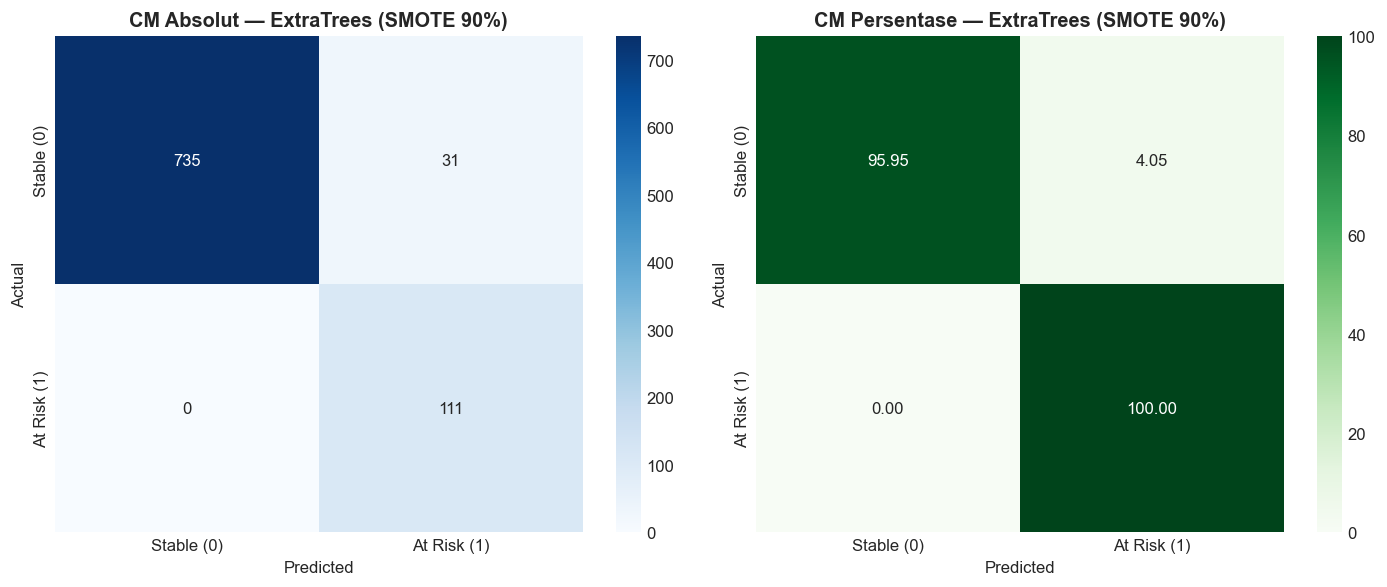


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.977
1,Random Forest,96.47,0.782,1.000,0.877,0.978
2,Logistic Regression,96.47,0.782,1.000,0.877,0.980
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.980
5,Gradient Boosting,96.12,0.777,0.973,0.864,0.977
6,Decision Tree,96.12,0.777,0.973,0.864,0.977


In [53]:
print('='*70)
print('KONDISI: SMOTE 90% (sampling_strategy=0.9)')
print('='*70)
print()

X_train_smote_90, y_train_smote_90, applied_90 = safe_smote_resample(X_train, y_train, 0.9)

print('Distribusi Kelas Latih Setelah SMOTE 90%:')
print(pd.Series(y_train_smote_90).value_counts())
print(f'Total sampel latih: {len(y_train_smote_90)}')
print()

df_res_90, trained_90 = evaluate_condition(X_train_smote_90, y_train_smote_90, X_test, y_test, 'SMOTE 90%')
all_conditions_results['SMOTE 90%'] = df_res_90
all_conditions_trained['SMOTE 90%'] = trained_90

best_name_90 = df_res_90.iloc[0]['Model']
best_acc_90 = df_res_90.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 90%'] = {
    'best_model_name': best_name_90,
    'best_accuracy': best_acc_90,
    'best_model': trained_90[best_name_90]
}

print(f'Model Terbaik: {best_name_90} — Accuracy: {best_acc_90}%')
print()

# Confusion Matrix untuk best model
y_pred_90 = trained_90[best_name_90].predict(X_test)
cm_90 = confusion_matrix(y_test, y_pred_90)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_90, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_90} (SMOTE 90%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_90 = cm_90.astype('float') / cm_90.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_90, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_90} (SMOTE 90%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_90, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_90


--- 
## 22. Evaluasi SMOTE 100% (`sampling_strategy=1.0`)
SMOTE oversampling dengan `sampling_strategy=1.0` — kelas minoritas di-oversample hingga 100% dari jumlah kelas mayoritas.


KONDISI: SMOTE 100% (sampling_strategy=1.0)

  Rasio saat ini: 0.1443 | Target interpolasi (100%): 1.0000
Distribusi Kelas Latih Setelah SMOTE 100%:
label
0    3064
1    3064
Name: count, dtype: int64
Total sampel latih: 6128

Model Terbaik: ExtraTrees — Accuracy: 96.47%



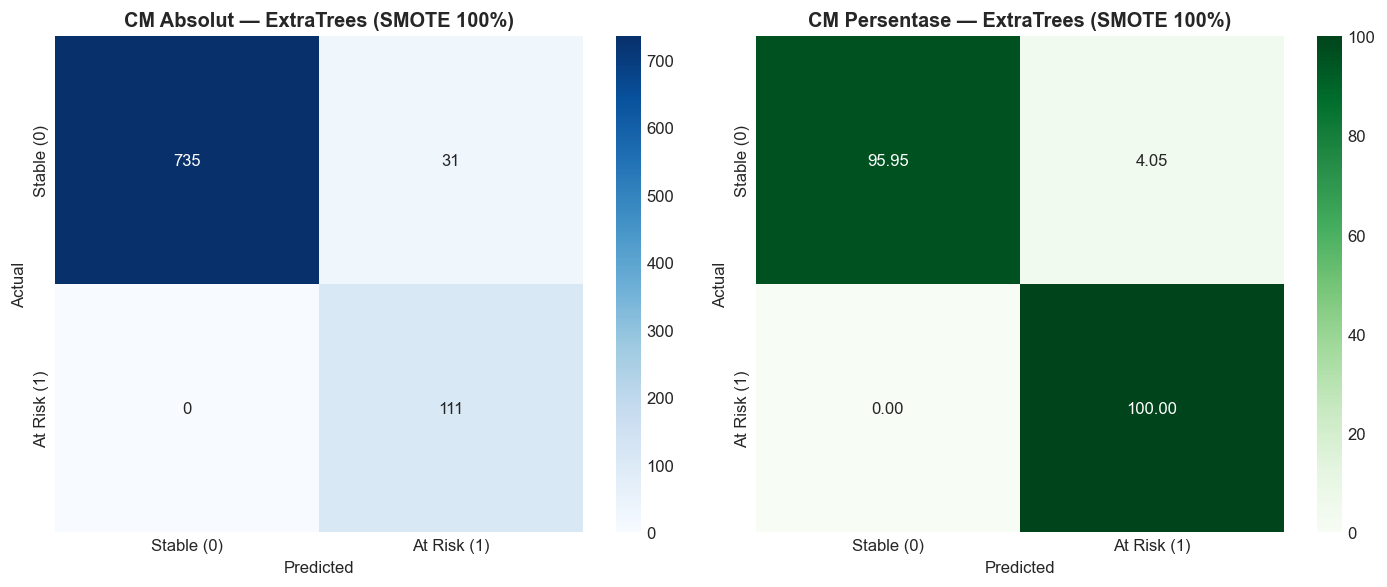


              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877




,Model,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,ExtraTrees,96.47,0.782,1.000,0.877,0.980
1,Random Forest,96.47,0.782,1.000,0.877,0.977
2,Logistic Regression,96.47,0.782,1.000,0.877,0.980
3,AdaBoost,96.35,0.780,0.991,0.873,0.980
4,HistGradientBoosting,96.35,0.780,0.991,0.873,0.981
5,Decision Tree,96.35,0.784,0.982,0.872,0.981
6,Gradient Boosting,96.24,0.779,0.982,0.869,0.976


In [54]:
print('='*70)
print('KONDISI: SMOTE 100% (sampling_strategy=1.0)')
print('='*70)
print()

X_train_smote_100, y_train_smote_100, applied_100 = safe_smote_resample(X_train, y_train, 1.0)

print('Distribusi Kelas Latih Setelah SMOTE 100%:')
print(pd.Series(y_train_smote_100).value_counts())
print(f'Total sampel latih: {len(y_train_smote_100)}')
print()

df_res_100, trained_100 = evaluate_condition(X_train_smote_100, y_train_smote_100, X_test, y_test, 'SMOTE 100%')
all_conditions_results['SMOTE 100%'] = df_res_100
all_conditions_trained['SMOTE 100%'] = trained_100

best_name_100 = df_res_100.iloc[0]['Model']
best_acc_100 = df_res_100.iloc[0]['Accuracy (%)']
all_conditions_best['SMOTE 100%'] = {
    'best_model_name': best_name_100,
    'best_accuracy': best_acc_100,
    'best_model': trained_100[best_name_100]
}

print(f'Model Terbaik: {best_name_100} — Accuracy: {best_acc_100}%')
print()

# Confusion Matrix untuk best model
y_pred_100 = trained_100[best_name_100].predict(X_test)
cm_100 = confusion_matrix(y_test, y_pred_100)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_100, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'CM Absolut — {best_name_100} (SMOTE 100%)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_perc_100 = cm_100.astype('float') / cm_100.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc_100, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'], yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'CM Persentase — {best_name_100} (SMOTE 100%)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_100, target_names=['Stable (0)', 'At Risk (1)']))
print()
df_res_100


--- 
## 23. Tabel Perbandingan Lengkap — Semua Kondisi SMOTE
Rangkuman **model terbaik** dari setiap kondisi SMOTE (Tanpa SMOTE, 10%, 20%, ..., 100%).


In [55]:
# Build comparison table
comparison_rows = []
for cond_name, info in all_conditions_best.items():
    best_df = all_conditions_results[cond_name]
    best_row = best_df.iloc[0]  # top model
    comparison_rows.append({
        'Kondisi SMOTE': cond_name,
        'Model Terbaik': info['best_model_name'],
        'Accuracy (%)': best_row['Accuracy (%)'],
        'Precision': best_row['Precision'],
        'Recall': best_row['Recall'],
        'F1-Score': best_row['F1-Score'],
        'AUC-ROC': best_row['AUC-ROC']
    })

df_comparison = pd.DataFrame(comparison_rows)

# Highlight the best overall
best_overall_idx = df_comparison['Accuracy (%)'].idxmax()
best_overall = df_comparison.loc[best_overall_idx]

print('='*80)
print('TABEL PERBANDINGAN LENGKAP — SEMUA KONDISI SMOTE')
print('='*80)
print()
print(df_comparison.to_string(index=False))
print()
print(f'>>> KONDISI TERBAIK OVERALL: {best_overall["Kondisi SMOTE"]} — {best_overall["Model Terbaik"]} — Accuracy: {best_overall["Accuracy (%)"]}%')
print()
df_comparison


TABEL PERBANDINGAN LENGKAP — SEMUA KONDISI SMOTE

Kondisi SMOTE Model Terbaik  Accuracy (%)  Precision  Recall  F1-Score  AUC-ROC
  Tanpa SMOTE    ExtraTrees         96.47      0.782     1.0     0.877    0.980
    SMOTE 10%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 20%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 30%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 40%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 50%    ExtraTrees         96.47      0.782     1.0     0.877    0.978
    SMOTE 60%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 70%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 80%    ExtraTrees         96.47      0.782     1.0     0.877    0.979
    SMOTE 90%    ExtraTrees         96.47      0.782     1.0     0.877    0.977
   SMOTE 100%    ExtraTrees         96.47      0.782     1.0     0.877

,Kondisi SMOTE,Model Terbaik,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,Tanpa SMOTE,ExtraTrees,96.47,0.782,1.0,0.877,0.980
1,SMOTE 10%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
2,SMOTE 20%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
3,SMOTE 30%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
4,SMOTE 40%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
5,SMOTE 50%,ExtraTrees,96.47,0.782,1.0,0.877,0.978
6,SMOTE 60%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
7,SMOTE 70%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
8,SMOTE 80%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
9,SMOTE 90%,ExtraTrees,96.47,0.782,1.0,0.877,0.977


--- 
## 24. Visualisasi Perbandingan Metrik per Kondisi SMOTE
Grafik batang dan line chart yang menunjukkan bagaimana setiap metrik berubah seiring perubahan `sampling_strategy`.


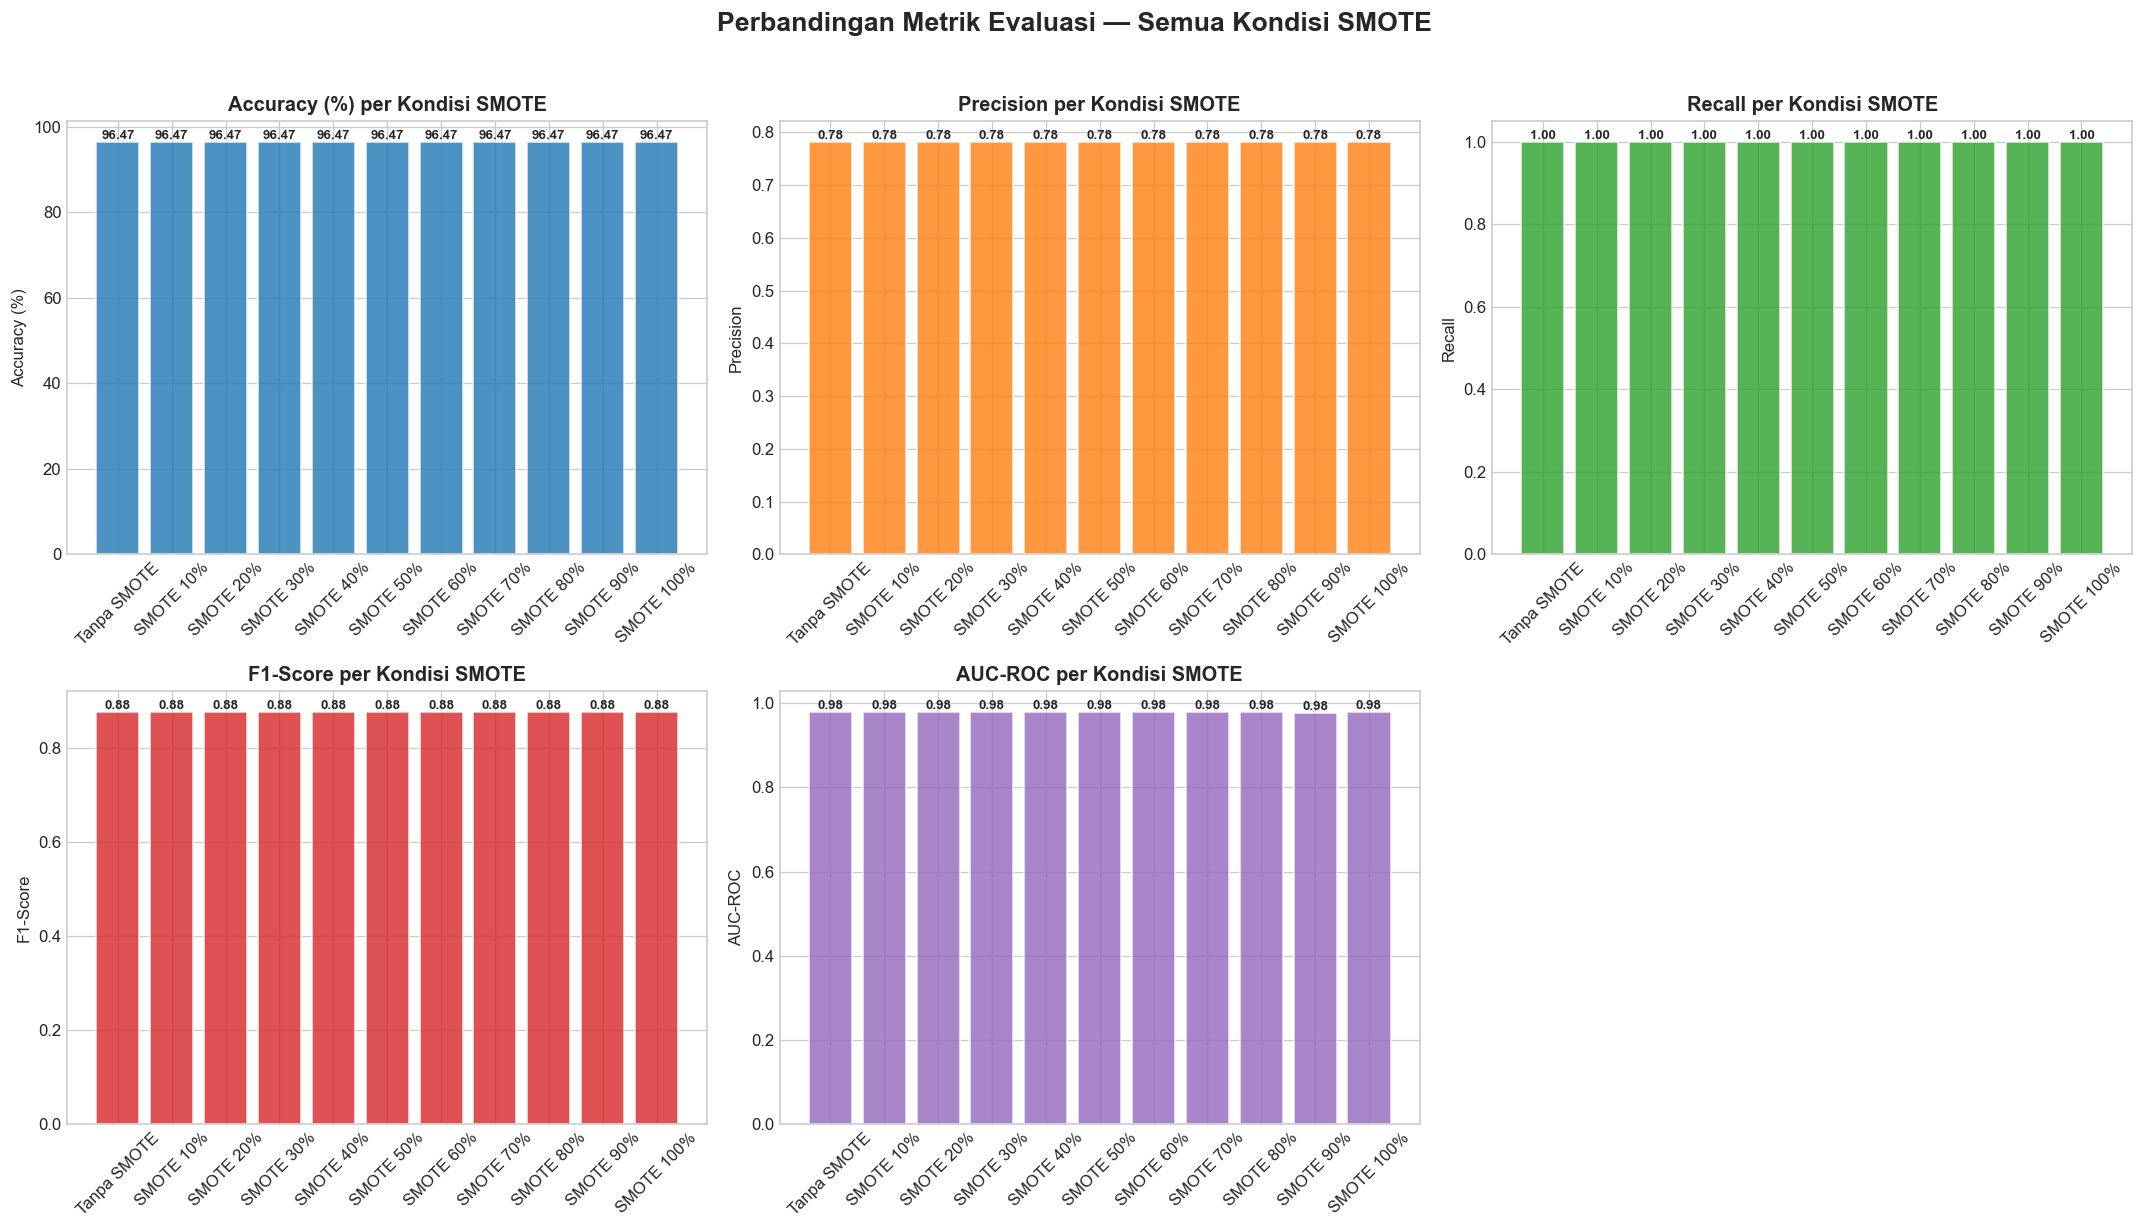

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['Accuracy (%)', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors_met = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 3, i % 3]
    bars = ax.bar(df_comparison['Kondisi SMOTE'], df_comparison[metric], 
                  color=colors_met[i], alpha=0.8, edgecolor='white', linewidth=1)
    ax.set_title(f'{metric} per Kondisi SMOTE', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

# Hide last subplot if odd number
if len(metrics_to_plot) % 3 != 0:
    axes[1, 2].axis('off')

plt.suptitle('Perbandingan Metrik Evaluasi — Semua Kondisi SMOTE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


--- 
## 24b. Line Chart Tren Metrik vs Kondisi SMOTE


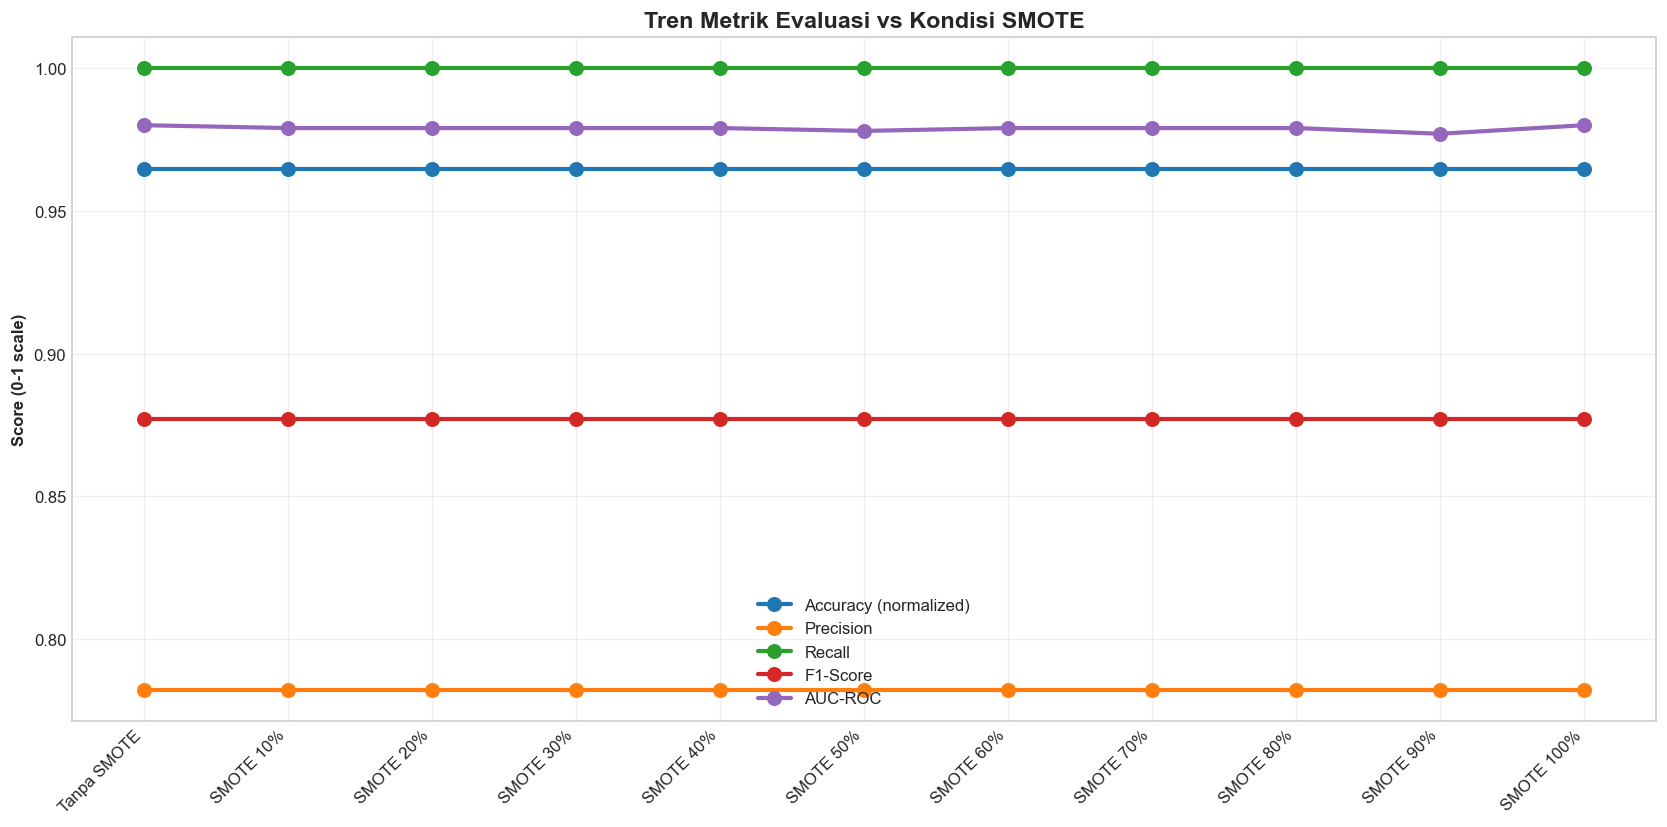

In [57]:
fig, ax = plt.subplots(figsize=(14, 7))

x_labels = df_comparison['Kondisi SMOTE'].tolist()
x_pos = range(len(x_labels))

for i, metric in enumerate(['Accuracy (%)', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']):
    values = df_comparison[metric].tolist()
    if metric == 'Accuracy (%)':
        values = [v / 100.0 for v in values]  # normalize to 0-1 scale
        label = 'Accuracy (normalized)'
    else:
        label = metric
    ax.plot(x_pos, values, 'o-', linewidth=2.5, markersize=8, label=label, color=colors_met[i])

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel('Score (0-1 scale)', fontweight='bold')
ax.set_title('Tren Metrik Evaluasi vs Kondisi SMOTE', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- 
## 25. Heatmap Metrik per Kondisi SMOTE
Visualisasi heatmap untuk melihat pola metrik secara keseluruhan.


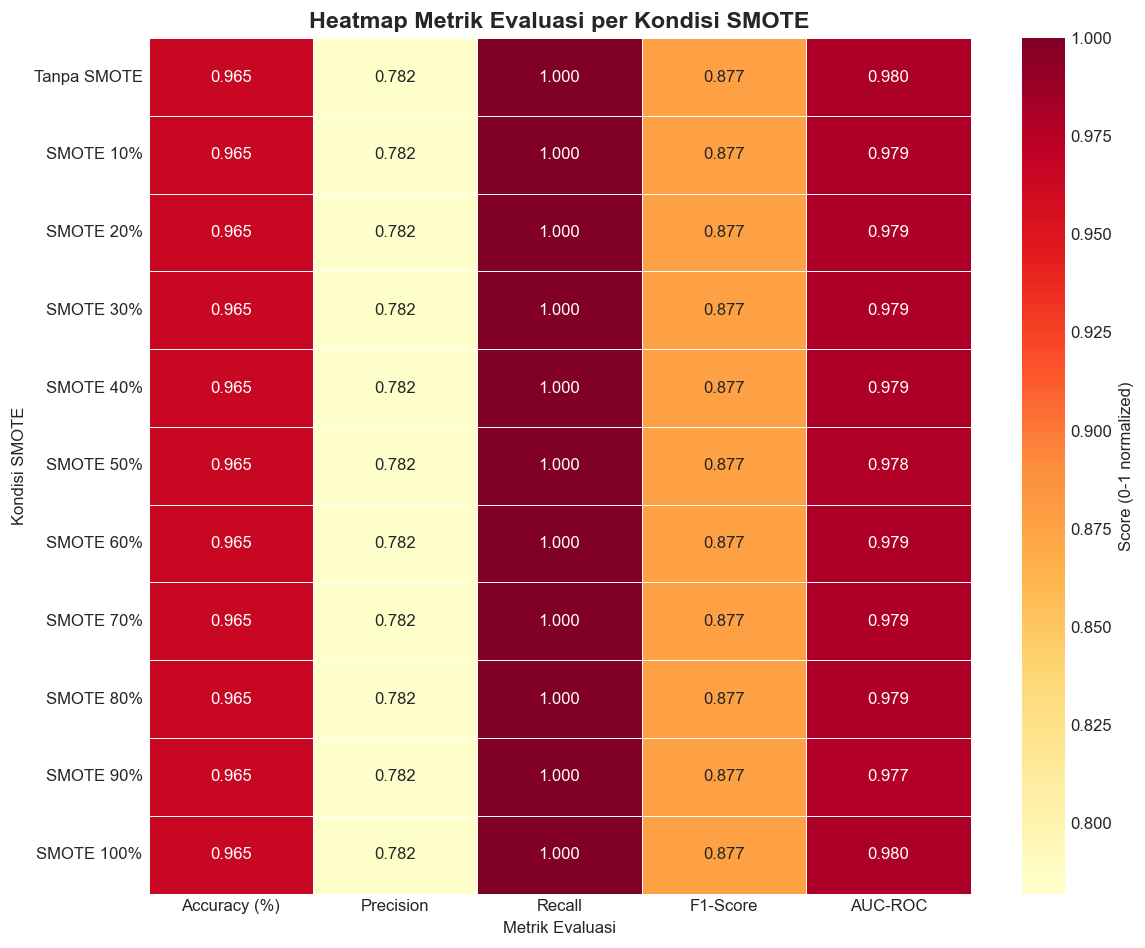

In [58]:
# Create heatmap data
heatmap_data = df_comparison.set_index('Kondisi SMOTE')[['Accuracy (%)', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].copy()
# Normalize Accuracy to 0-1 for consistent heatmap
heatmap_data['Accuracy (%)'] = heatmap_data['Accuracy (%)'] / 100.0

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Score (0-1 normalized)'})
plt.title('Heatmap Metrik Evaluasi per Kondisi SMOTE', fontweight='bold', fontsize=14)
plt.ylabel('Kondisi SMOTE')
plt.xlabel('Metrik Evaluasi')
plt.tight_layout()
plt.show()


--- 
## 26. Confusion Matrix Grid — Semua Kondisi SMOTE (Model Terbaik per Kondisi)
Grid 3×4 menampilkan confusion matrix dari model terbaik di setiap kondisi SMOTE.


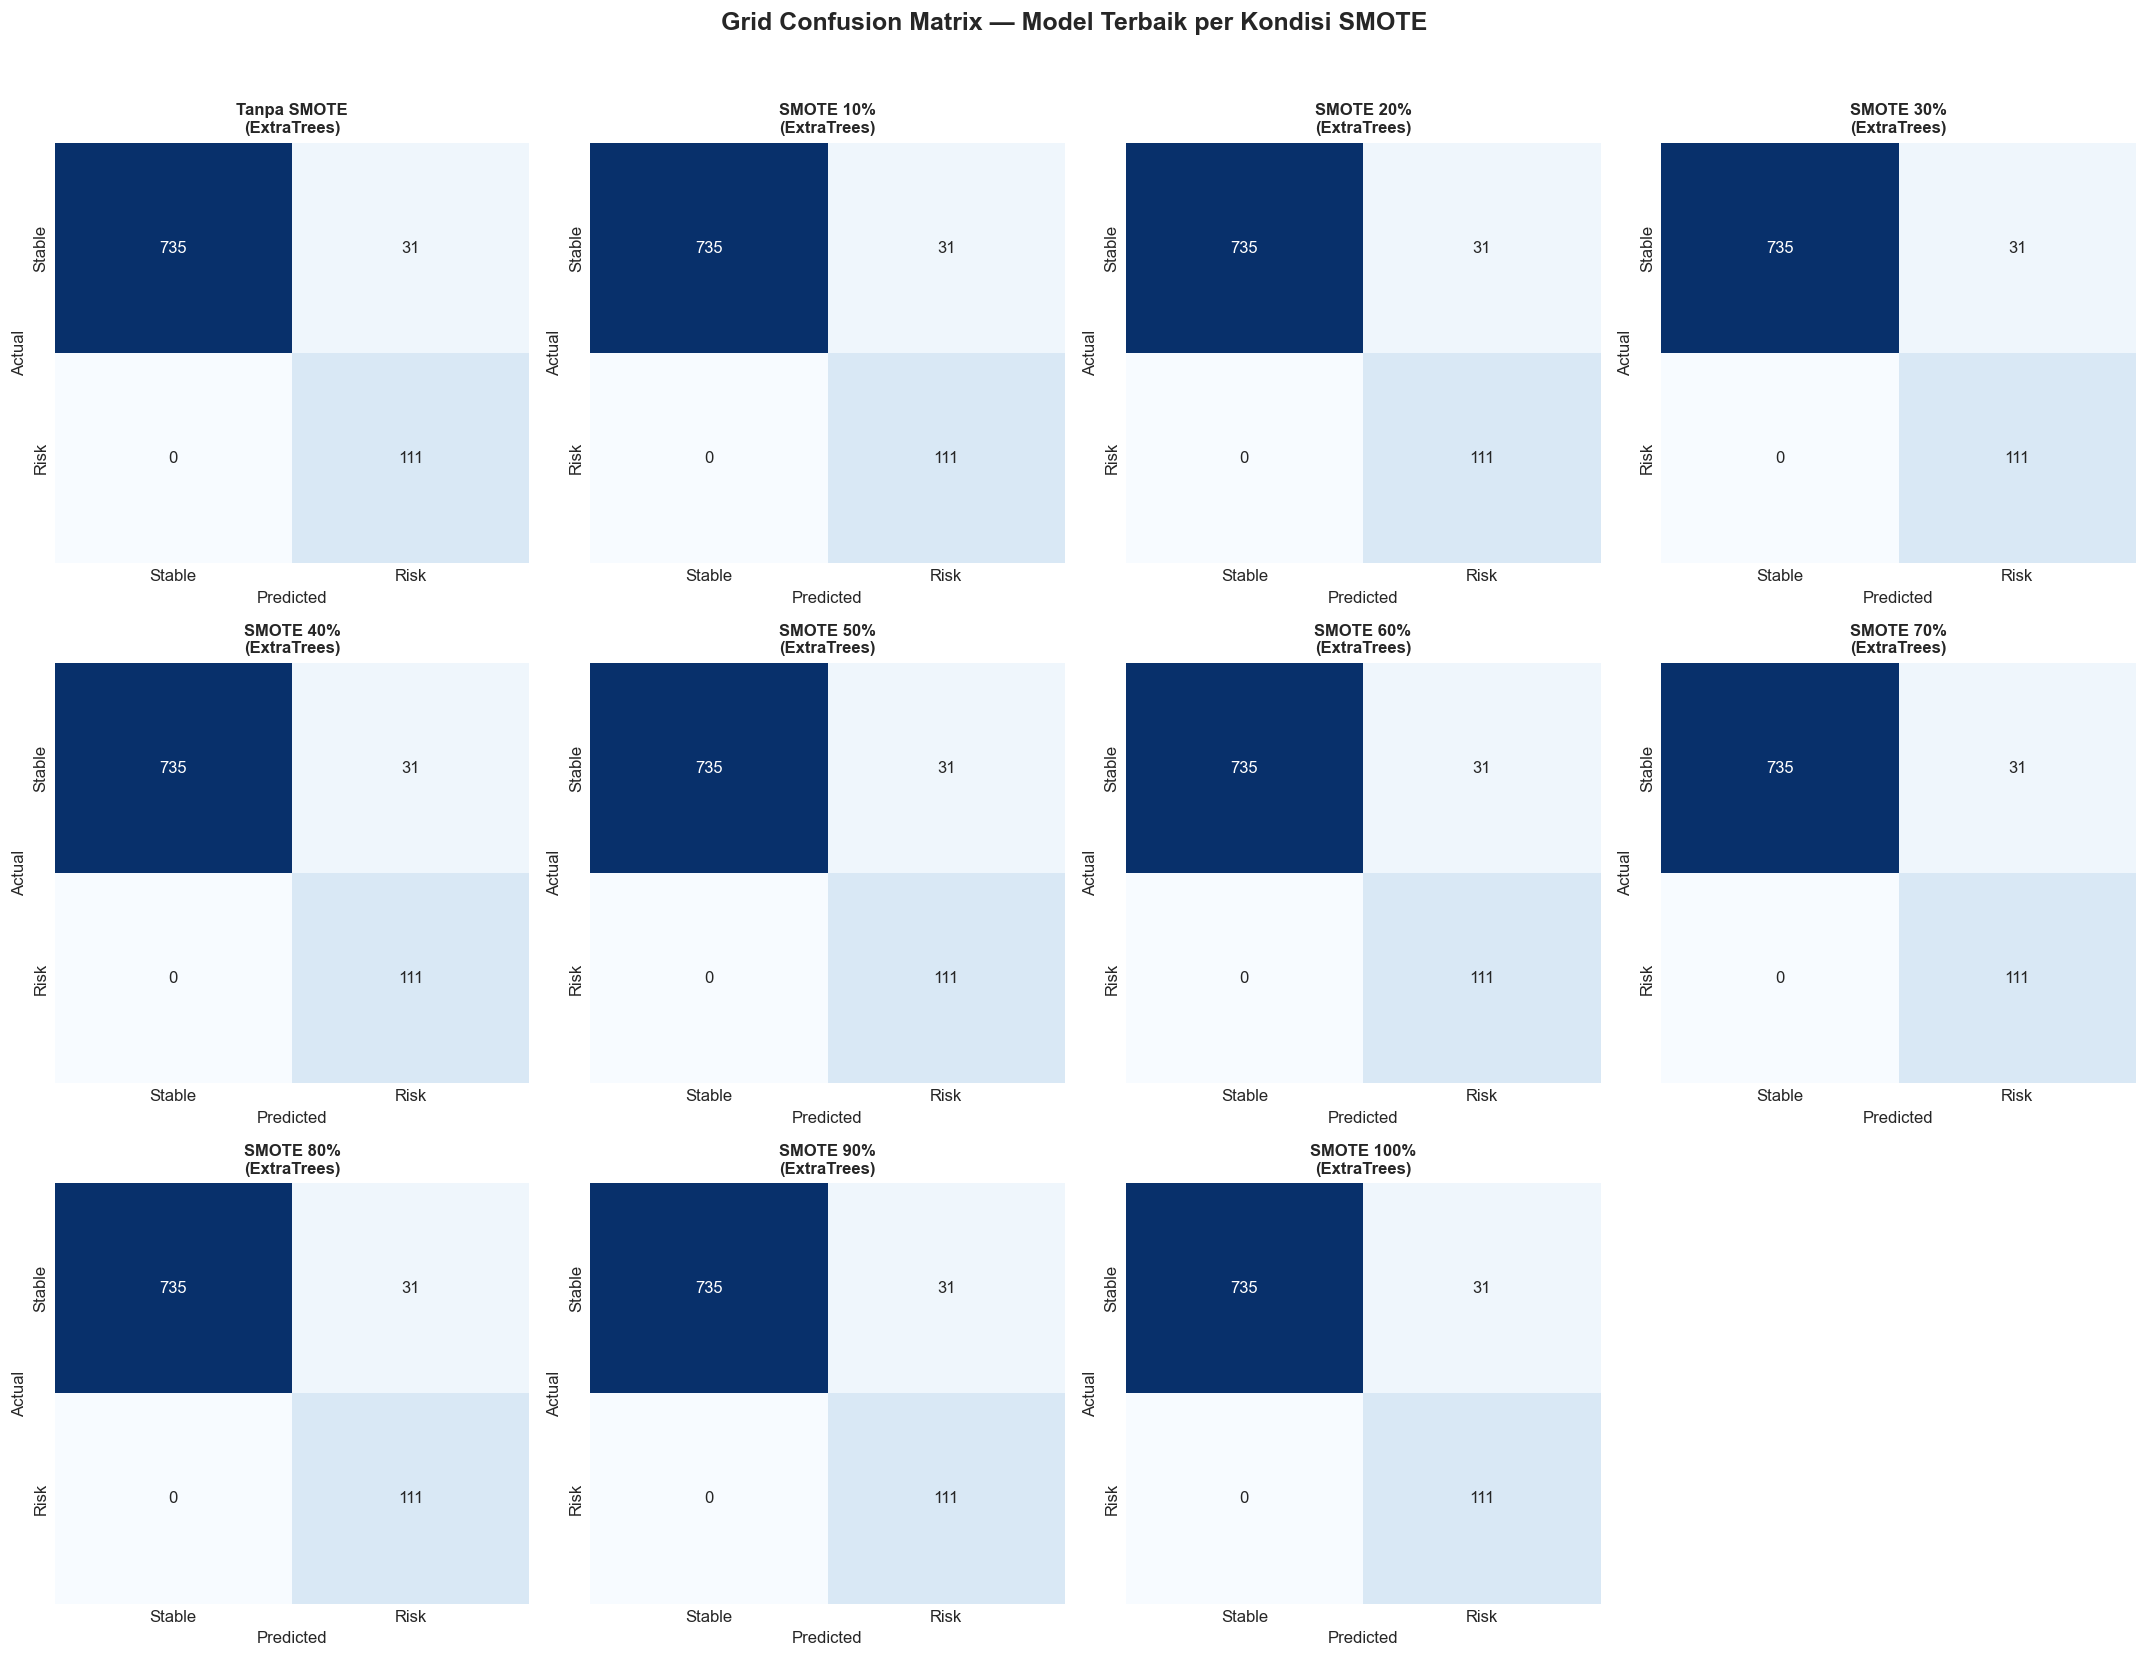

In [59]:
condition_names = list(all_conditions_best.keys())
n_conditions = len(condition_names)
n_cols = 4
n_rows = (n_conditions + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten()

for i, cond_name in enumerate(condition_names):
    best_m = all_conditions_best[cond_name]['best_model']
    y_pred_c = best_m.predict(X_test)
    cm_c = confusion_matrix(y_test, y_pred_c)
    
    sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Stable', 'Risk'], yticklabels=['Stable', 'Risk'])
    axes[i].set_title(f'{cond_name}\n({all_conditions_best[cond_name]["best_model_name"]})', 
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused subplots
for j in range(n_conditions, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Grid Confusion Matrix — Model Terbaik per Kondisi SMOTE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


--- 
## 27. ROC Curve Overlay — Semua Kondisi SMOTE (Model Terbaik per Kondisi)
Membandingkan ROC curve dari model terbaik di setiap kondisi SMOTE dalam satu plot.


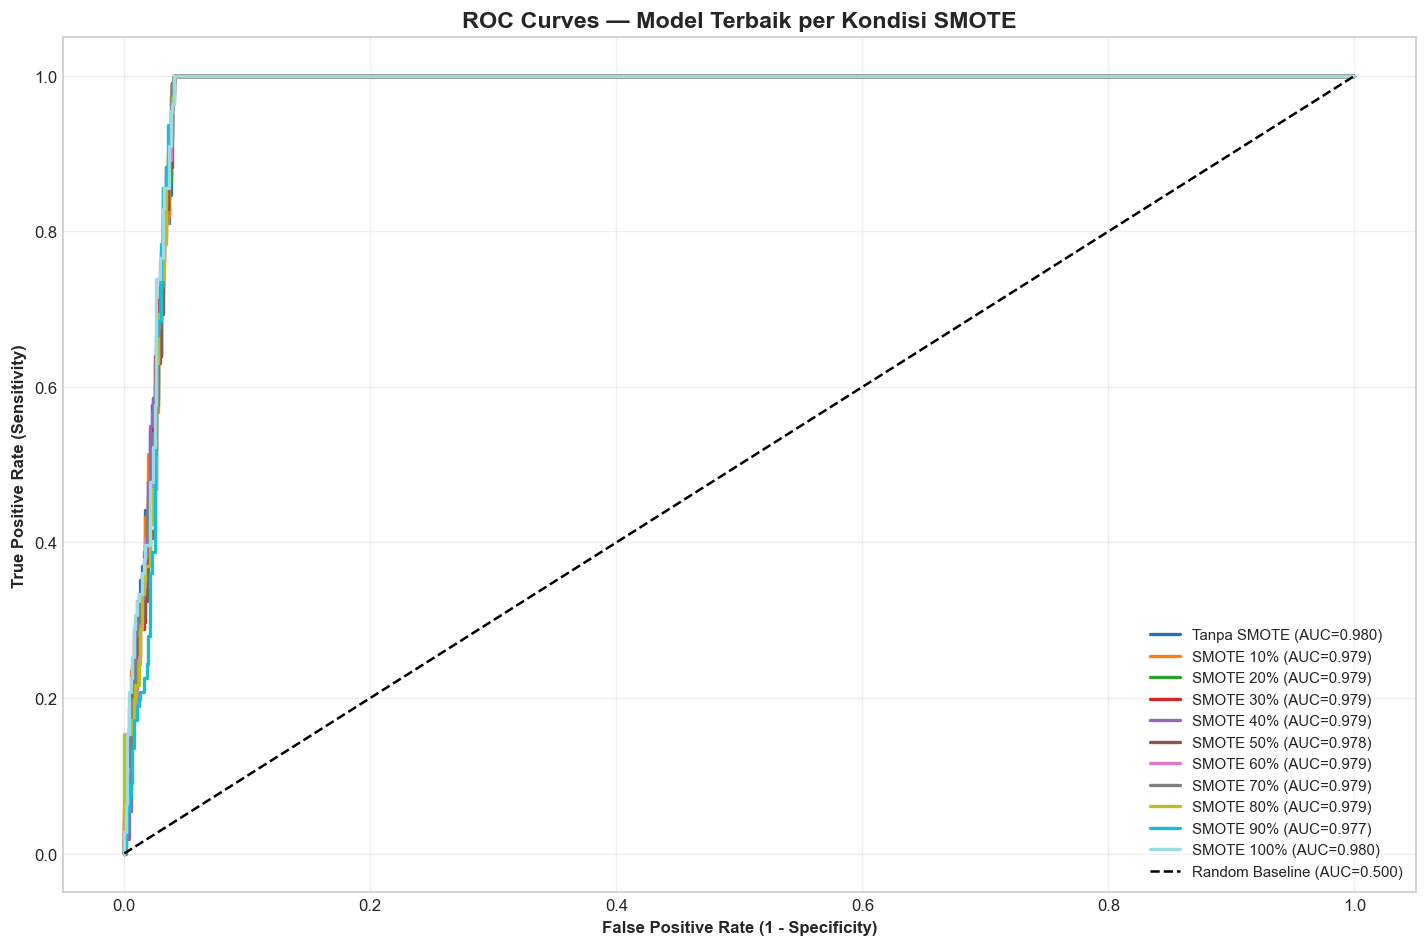

In [60]:
plt.figure(figsize=(12, 8))

condition_names = list(all_conditions_best.keys())
colors_roc = plt.cm.tab20(np.linspace(0, 1, len(condition_names)))

for i, cond_name in enumerate(condition_names):
    best_m = all_conditions_best[cond_name]['best_model']
    if hasattr(best_m, 'predict_proba'):
        y_prob_c = best_m.predict_proba(X_test)[:, 1]
        fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_c)
        auc_c = roc_auc_score(y_test, y_prob_c)
        plt.plot(fpr_c, tpr_c, label=f'{cond_name} (AUC={auc_c:.3f})', 
                 linewidth=2, color=colors_roc[i])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline (AUC=0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
plt.title('ROC Curves — Model Terbaik per Kondisi SMOTE', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- 
## 28. Kesimpulan & Rekomendasi Kondisi SMOTE Terbaik


In [61]:
print('='*80)
print('KESIMPULAN & REKOMENDASI')
print('='*80)
print()

# Find overall best
best_idx = df_comparison['Accuracy (%)'].idxmax()
best_cond = df_comparison.loc[best_idx]

print(f'Kondisi SMOTE Terbaik Berdasarkan Accuracy:')
print(f'   Kondisi       : {best_cond["Kondisi SMOTE"]}')
print(f'   Model Terbaik : {best_cond["Model Terbaik"]}')
print(f'   Accuracy      : {best_cond["Accuracy (%)"]}%')
print(f'   Precision     : {best_cond["Precision"]}')
print(f'   Recall        : {best_cond["Recall"]}')
print(f'   F1-Score      : {best_cond["F1-Score"]}')
print(f'   AUC-ROC       : {best_cond["AUC-ROC"]}')
print()

# Also find best by F1-Score (important for imbalanced data)
best_f1_idx = df_comparison['F1-Score'].idxmax()
best_f1_cond = df_comparison.loc[best_f1_idx]

print(f'Kondisi SMOTE Terbaik Berdasarkan F1-Score (penting untuk data imbalanced):')
print(f'   Kondisi       : {best_f1_cond["Kondisi SMOTE"]}')
print(f'   Model Terbaik : {best_f1_cond["Model Terbaik"]}')
print(f'   F1-Score      : {best_f1_cond["F1-Score"]}')
print(f'   Accuracy      : {best_f1_cond["Accuracy (%)"]}%')
print()

# Also find best by Recall (important for "At Risk" detection)
best_rec_idx = df_comparison['Recall'].idxmax()
best_rec_cond = df_comparison.loc[best_rec_idx]

print(f'Kondisi SMOTE Terbaik Berdasarkan Recall (deteksi At Risk):')
print(f'   Kondisi       : {best_rec_cond["Kondisi SMOTE"]}')
print(f'   Model Terbaik : {best_rec_cond["Model Terbaik"]}')
print(f'   Recall        : {best_rec_cond["Recall"]}')
print(f'   Accuracy      : {best_rec_cond["Accuracy (%)"]}%')
print()

print('Tabel Final Lengkap:')
df_comparison


KESIMPULAN & REKOMENDASI

Kondisi SMOTE Terbaik Berdasarkan Accuracy:
   Kondisi       : Tanpa SMOTE
   Model Terbaik : ExtraTrees
   Accuracy      : 96.47%
   Precision     : 0.782
   Recall        : 1.0
   F1-Score      : 0.877
   AUC-ROC       : 0.98

Kondisi SMOTE Terbaik Berdasarkan F1-Score (penting untuk data imbalanced):
   Kondisi       : Tanpa SMOTE
   Model Terbaik : ExtraTrees
   F1-Score      : 0.877
   Accuracy      : 96.47%

Kondisi SMOTE Terbaik Berdasarkan Recall (deteksi At Risk):
   Kondisi       : Tanpa SMOTE
   Model Terbaik : ExtraTrees
   Recall        : 1.0
   Accuracy      : 96.47%

Tabel Final Lengkap:


,Kondisi SMOTE,Model Terbaik,Accuracy (%),Precision,Recall,F1-Score,AUC-ROC
0,Tanpa SMOTE,ExtraTrees,96.47,0.782,1.0,0.877,0.980
1,SMOTE 10%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
2,SMOTE 20%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
3,SMOTE 30%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
4,SMOTE 40%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
5,SMOTE 50%,ExtraTrees,96.47,0.782,1.0,0.877,0.978
6,SMOTE 60%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
7,SMOTE 70%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
8,SMOTE 80%,ExtraTrees,96.47,0.782,1.0,0.877,0.979
9,SMOTE 90%,ExtraTrees,96.47,0.782,1.0,0.877,0.977


--- 
## 29. Save Model & Features Terbaik


In [62]:
# Save the best overall model
best_overall_cond = df_comparison.loc[df_comparison['Accuracy (%)'].idxmax(), 'Kondisi SMOTE']
best_overall_model = all_conditions_best[best_overall_cond]['best_model']
best_overall_name = all_conditions_best[best_overall_cond]['best_model_name']

joblib.dump(best_overall_model, 'aquaagent_rf_v4_v3.pkl')
joblib.dump(feature_cols, 'rf_features_v4_v3.pkl')

print(f'Model terbaik ({best_overall_name} dari {best_overall_cond}) dan daftar {len(feature_cols)} fitur berhasil disimpan:')
print('   - Model File: aquaagent_rf_v4_v3.pkl')
print('   - Features File: rf_features_v4_v3.pkl')
print()
print('Notebook Full Kondisi SMOTE Comparison selesai!')


Model terbaik (ExtraTrees dari Tanpa SMOTE) dan daftar 15 fitur berhasil disimpan:
   - Model File: aquaagent_rf_v4_v3.pkl
   - Features File: rf_features_v4_v3.pkl

Notebook Full Kondisi SMOTE Comparison selesai!
